***
# <font color=green size=10>ESTATÍSTICA DESCRITIVA (PARTE 1)</font>
***

Execute o comando abaixo para montar a pasta do seu Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import pandas as pd
dados = pd.read_csv('/content/drive/MyDrive/Curso/dados.csv')

In [3]:
type(dados)

pandas.core.frame.DataFrame

In [4]:
dados

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631
...,...,...,...,...,...,...,...
76835,53,1,46,2,11,812,1.687030
76836,53,0,30,4,7,1500,1.792934
76837,53,0,32,8,12,1300,1.830587
76838,53,0,57,8,4,1500,1.726344


In [5]:
dados.head ()

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [6]:
dados.tail ()

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
76835,53,1,46,2,11,812,1.687030
76836,53,0,30,4,7,1500,1.792934
76837,53,0,32,8,12,1300,1.830587
76838,53,0,57,8,4,1500,1.726344
76839,53,0,38,8,4,900,1.658305


# <font color=green>1 CONHECENDO OS DADOS</font>
***

## <font color=green>1.1 Dataset do projeto</font>
***

### Pesquisa Nacional por Amostra de Domicílios - 2015

A <b>Pesquisa Nacional por Amostra de Domicílios - PNAD</b> investiga anualmente, de forma permanente, características gerais da população, de educação, trabalho, rendimento e habitação e outras, com periodicidade variável, de acordo com as necessidades de informação para o país, como as características sobre migração, fecundidade, nupcialidade, saúde, segurança alimentar, entre outros temas. O levantamento dessas estatísticas constitui, ao longo dos 49 anos de realização da pesquisa, um importante instrumento para formulação, validação e avaliação de políticas orientadas para o desenvolvimento socioeconômico e a melhoria das condições de vida no Brasil.

### Fonte dos Dados

https://www.ibge.gov.br/estatisticas/sociais/populacao/9127-pesquisa-nacional-por-amostra-de-domicilios.html?=&t=microdados

### Variáveis utilizadas

> ### Renda
> ***

Rendimento mensal do trabalho principal para pessoas de 10 anos ou mais de idade.

> ### Idade
> ***

Idade do morador na data de referência em anos.

> ### Altura (elaboração própria)
> ***

Altura do morador em metros.

> ### UF
> ***

|Código|Descrição|
|---|---|
|11|Rondônia|
|12|Acre|
|13|Amazonas|
|14|Roraima|
|15|Pará|
|16|Amapá|
|17|Tocantins|
|21|Maranhão|
|22|Piauí|
|23|Ceará|
|24|Rio Grande do Norte|
|25|Paraíba|
|26|Pernambuco|
|27|Alagoas|
|28|Sergipe|
|29|Bahia|
|31|Minas Gerais|
|32|Espírito Santo|
|33|Rio de Janeiro|
|35|São Paulo|
|41|Paraná|
|42|Santa Catarina|
|43|Rio Grande do Sul|
|50|Mato Grosso do Sul|
|51|Mato Grosso|
|52|Goiás|
|53|Distrito Federal|

> ### Sexo
> ***

|Código|Descrição|
|---|---|
|0|Masculino|
|1|Feminino|

> ### Anos de Estudo
> ***

|Código|Descrição|
|---|---|
|1|Sem instrução e menos de 1 ano|
|2|1 ano|
|3|2 anos|
|4|3 anos|
|5|4 anos|
|6|5 anos|
|7|6 anos|
|8|7 anos|
|9|8 anos|
|10|9 anos|
|11|10 anos|
|12|11 anos|
|13|12 anos|
|14|13 anos|
|15|14 anos|
|16|15 anos ou mais|
|17|Não determinados|
||Não aplicável|

> ### Cor
> ***

|Código|Descrição|
|---|---|
|0|Indígena|
|2|Branca|
|4|Preta|
|6|Amarela|
|8|Parda|
|9|Sem declaração|

#### <font color='red'>Observação</font>
***
> Os seguintes tratamentos foram realizados nos dados originais:
> 1. Foram eliminados os registros onde a <b>Renda</b> era inválida (999 999 999 999);
> 2. Foram eliminados os registros onde a <b>Renda</b> era missing;
> 3. Foram considerados somente os registros das <b>Pessoas de Referência</b> de cada domicílio (responsável pelo domicílio).

### Importando pandas e lendo o dataset do projeto

https://pandas.pydata.org/

## <font color=green>1.2 Configuração</font>
***

Recentemente, com o lançamento da versão 2.0 da biblioteca `NumPy` houve uma mudança na saída de várias funções executadas dentro do Google Colab, que passaram a mostrar o tipo do dado numérico em vez de somente o dado em si.

A partir dessa versão global, a comunidade adotou a proposta técnica `NEP 51`, que mudou a representação em texto (*string representation*) de escalares isolados do NumPy.

Por exemplo, em vez da saída ser 10, o *notebook* mostra `np.int64(10)`.

A justificativa para essa mudança é que o formato antigo causava muita confusão e *bugs* ocultos, porque o usuário achava que estava lidando com um `int` nativo do Python, quando na verdade era um objeto `np.int64`. Esses tipos ocultos quebravam códigos ao tentar salvar arquivos em formatos como JSON (que não aceita `np.int64` nativamente).Agora, para deixar o código transparente, o NumPy força a exibição do tipo real ao imprimir elementos isolados ou dentro de estruturas (como tuplas e dicionários).

Caso deseje manter a saída antiga / convencional, pois a considera mais limpa, execute o comando a seguir:

In [7]:
import numpy as np
np.set_printoptions(legacy="1.25")

## <font color=green>1.3 Tipos de dados</font>
***

### Classificação de uma variável
<img src='https://caelum-online-public.s3.amazonaws.com/1177-estatistica-parte1/01/img001.png' width='70%'>

#### <font color='red'>Observação</font>
***
> A variável idade pode ser classificada de três formas distintas:
> 1. <b>QUANTITATIVA DISCRETA</b> - quando representa anos completos (números inteiros);
> 2. <b>QUANTITATIVA CONTÍNUA</b> - quando representa a idade exata, sendo representado por frações de anos; e
> 3. <b>QUALITATIVA ORDINAL</b> - quando representa faixas de idade.

### Variáveis qualitativas ordinais

► Variáveis que podem ser ordenadas ou hierarquizardas

In [8]:
sorted(dados['Anos de Estudo'].unique())

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

### Variáveis qualitativas nominais

► Variáveis que não podem ser ordenadas ou hierarquizardas

In [9]:
sorted(dados['Sexo'].unique())

[0, 1]

In [10]:
sorted(dados['Cor'].unique())

[0, 2, 4, 6, 8]

### Variáveis quantitativas discretas

► Variáveis que representam uma contagem onde os valores possíveis formam um conjunto finito ou enumerável.

In [11]:
print(f'Idades vão de {dados.Idade.min()} a {dados.Idade.max()}anos')

Idades vão de 13 a 99anos


### Variáveis quantitativas contínuas

► Variáveis que representam uma contagem ou mensuração que assumem valores em uma escala contínua (números reais).

In [12]:
print(f'Alturas vão de {dados.Altura.min()} a {dados.Altura.max()}metros')

Alturas vão de 1.339244614 a 2.028496765metros


In [13]:
print(f'Alturas vão de {dados.Altura.min():.2f} a {dados.Altura.max():.2f}metros')

Alturas vão de 1.34 a 2.03metros


# <font color=green>2 DISTRIBUIÇÃO DE FREQUÊNCIAS</font>
***

O primeiro passo em um trabalho de análise é o conhecimento do comportamento das variáveis envolvidas no estudo. Utilizando técnicas estatísticas como as análises das <b>DISTRIBUIÇÕES DE FREQUÊNCIAS</b> e <b>HISTOGRAMAS</b> podemos avaliar melhor a forma como os fenômenos em estudo se distribuem.

## <font color=green>2.1 Distribuição de frequências para variáveis qualitativas</font>
***

### Método 1

Utilização do método `value_counts()`:
https://pandas.pydata.org/docs/reference/api/pandas.Series.value_counts.html

In [14]:
dados['Sexo'].value_counts()

,count
Sexo,
0,53250
1,23590


In [15]:
dados['Sexo'].value_counts(normalize=True)

,proportion
Sexo,
0,0.692998
1,0.307002


In [16]:
frequencia = dados ['Sexo'].value_counts()

In [17]:
percentual = dados ['Sexo'].value_counts(normalize=True) * 100

In [18]:
distr_freq_quali=pd.DataFrame({'Frequência': frequencia, 'Porcentagem (%)': percentual})

In [19]:
distr_freq_quali

,Frequência,Porcentagem (%)
Sexo,,
0,53250,69.299844
1,23590,30.700156


In [20]:
distr_freq_quali.rename(index={0: 'Masculino', 1: 'Feminino'}, inplace=True)

In [21]:
distr_freq_quali

,Frequência,Porcentagem (%)
Sexo,,
Masculino,53250,69.299844
Feminino,23590,30.700156


In [22]:
distr_freq_quali.rename_axis('tabela', axis='columns', inplace=True)
distr_freq_quali

tabela,Frequência,Porcentagem (%)
Sexo,,
Masculino,53250,69.299844
Feminino,23590,30.700156


In [23]:
distr_freq_quali.rename_axis('columns',inplace=True)
distr_freq_quali

tabela,Frequência,Porcentagem (%)
columns,,
Masculino,53250,69.299844
Feminino,23590,30.700156


In [24]:
distr_freq_quali

tabela,Frequência,Porcentagem (%)
columns,,
Masculino,53250,69.299844
Feminino,23590,30.700156


In [25]:
distr_freq_quali.rename_axis(columns=None, inplace=True)

In [26]:
distr_freq_quali_single_header = distr_freq_quali.reset_index()

In [27]:
distr_freq_quali_single_header

,columns,Frequência,Porcentagem (%)
0,Masculino,53250,69.299844
1,Feminino,23590,30.700156


In [28]:
freq_anos_estudo = dados['Anos de Estudo'].value_counts()

In [29]:
perc_anos_estudo = dados['Anos de Estudo'].value_counts(normalize=True) * 100

In [30]:
#cria DataFrame combinando as duas séries
dist_freq_anos_estudo=pd.DataFrame({
    'Frequência': freq_anos_estudo,
    'Porcentagem (%)': perc_anos_estudo
})
dist_freq_anos_estudo.head()

,Frequência,Porcentagem (%)
Anos de Estudo,,
12,20848,27.131702
16,10795,14.048673
9,7980,10.385216
5,6729,8.757158
1,5849,7.611921


Índices:

In [31]:
#informações dos índices
print('índice:', dist_freq_anos_estudo.index.name)
print(dist_freq_anos_estudo.columns)

#acessando a linha cujo rótulo ho índice é igual ao número 5
print()
print('Linha 5:', dist_freq_anos_estudo.loc[5])

#mostra a mesma linha de cima, mas somente a coluna 'Frequência'
print('---')
print("Linha 5, coluna 'Frequência':", dist_freq_anos_estudo.loc[5])

índice: Anos de Estudo
Index(['Frequência', 'Porcentagem (%)'], dtype='object')

Linha 5: Frequência         6729.000000
Porcentagem (%)       8.757158
Name: 5, dtype: float64
---
Linha 5, coluna 'Frequência': Frequência         6729.000000
Porcentagem (%)       8.757158
Name: 5, dtype: float64


In [32]:
#reset_index() transforma o índice atual das linhas em uma coluna comum
# do DataFrame e cria um novo índice numérico sequencial (começando do 0)
dist_freq_anos_estudo.index.name = 'Índice'

#Da um nome interno a tabela
dist_freq_anos_estudo.name = 'Relatório de Anos de Estudo'

display(dist_freq_anos_estudo.head(6))

print('\nInformações do DataFrame após as alterações:')
dist_freq_anos_estudo.info()

#informações dos índices
print('\nÍndice:', dist_freq_anos_estudo.index.name)
print(dist_freq_anos_estudo.columns)

#Acessando linha 5 (física) com índice numérico
print()
print(dist_freq_anos_estudo.loc[5])

,Frequência,Porcentagem (%)
Índice,,
12,20848,27.131702
16,10795,14.048673
9,7980,10.385216
5,6729,8.757158
1,5849,7.611921
6,4499,5.855023



Informações do DataFrame após as alterações:
<class 'pandas.core.frame.DataFrame'>
Index: 17 entries, 12 to 17
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Frequência       17 non-null     int64  
 1   Porcentagem (%)  17 non-null     float64
dtypes: float64(1), int64(1)
memory usage: 964.0 bytes

Índice: Índice
Index(['Frequência', 'Porcentagem (%)'], dtype='object')

Frequência         6729.000000
Porcentagem (%)       8.757158
Name: 5, dtype: float64


In [33]:
#Limpa o nome do índice (remove o desalinhamento)
dist_freq_anos_estudo.index.name = None

In [34]:
#Define o nome no eixo das colunas (joga o testo para a mesma linha)
dist_freq_anos_estudo.rename_axis('Índice', axis= 'columns', inplace=True)

In [35]:
dist_freq_anos_estudo.sort_values(by='Frequência', ascending=False, inplace=True)

In [36]:
#Se fosse variável normal
print('------')

------


In [37]:
print(dist_freq_anos_estudo[dist_freq_anos_estudo.index == 5])

Índice  Frequência  Porcentagem (%)
5             6729         8.757158


In [38]:
dist_freq_anos_estudo.head().style.format({
    'Frequência': lambda x: f'{x:,.0f}'.replace(',','.'), #formato de milhar brasileiro (ponto)
    'Porcentagem (%)': lambda x: f'{x:.2f}%'.replace('.',',') #duas casas decimais e símbolo %
}).highlight_max(subset=['Porcentagem (%)'], color='lightgreen')

Índice,Frequência,Porcentagem (%)
12,20.848,"27,13%"
16,10.795,"14,05%"
9,7.980,"10,39%"
5,6.729,"8,76%"
1,5.849,"7,61%"


In [39]:
distr_freq_quali.rename_axis('tabela', axis='columns',inplace=True)

In [40]:
distr_freq_quali

tabela,Frequência,Porcentagem (%)
columns,,
Masculino,53250,69.299844
Feminino,23590,30.700156


In [41]:
distr_freq_quali.rename_axis(columns=None, inplace=True)

In [42]:
distr_freq_quali

,Frequência,Porcentagem (%)
columns,,
Masculino,53250,69.299844
Feminino,23590,30.700156


In [43]:
distr_freq_quali.rename_axis('tabela', axis='columns', inplace=True)

In [44]:
distr_freq_quali.rename_axis(columns=None, inplace=True)

In [45]:
distr_freq_quali

,Frequência,Porcentagem (%)
columns,,
Masculino,53250,69.299844
Feminino,23590,30.700156


In [46]:
import matplotlib.pyplot as plt

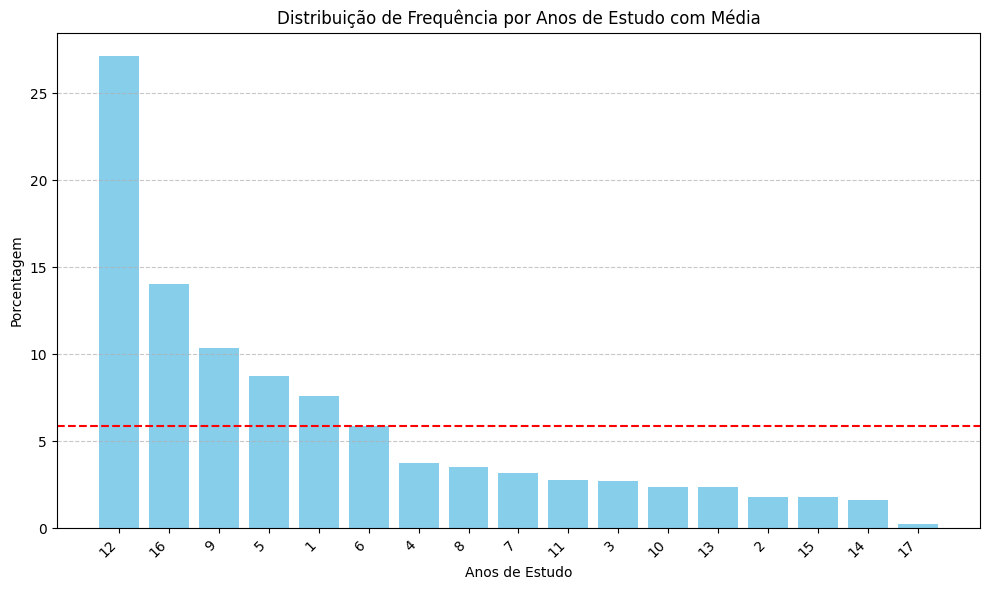

In [47]:
import matplotlib.pyplot as plt

#Criar o gráfico de barras
plt.figure(figsize=(10,6))
plt.bar(dist_freq_anos_estudo.index.astype(str),
        dist_freq_anos_estudo['Porcentagem (%)'], color= 'skyblue', label= 'Porcentagem por Anos de Estudo')

#calcular a média da porcentagem para a linha média
media_porcentagem = dist_freq_anos_estudo['Porcentagem (%)'].mean()

#Adicionar linha média horizontal
plt.axhline(y=media_porcentagem, color='red', linestyle='--', label=f'Média: {media_porcentagem:.2f}%')

#Adicionar rótulos e títulos
plt.xlabel('Anos de Estudo')
plt.ylabel('Porcentagem')
plt.title('Distribuição de Frequência por Anos de Estudo com Média')
plt.xticks(rotation=45, ha='right') #rotacionar os rótulos do eixo X para melhor visualização
plt.grid(axis='y', linestyle='--',alpha=0.7) #Adicionar grade no eixo Y
plt.tight_layout() #Ajustar o layout para evitar sobreposição
#exibir o gráfico
plt.show()

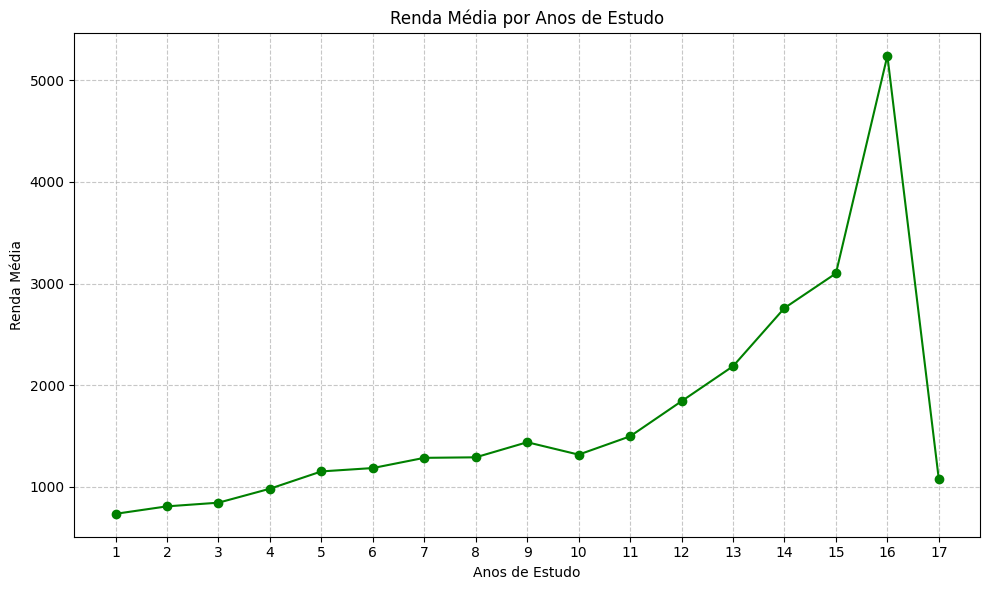

In [48]:
import matplotlib.pyplot as plt

#agrupa dados por 'Anos de Estudo' e calcula a média da 'Renda'
renda_por_anos_estudo = dados.groupby('Anos de Estudo')['Renda'].mean().reset_index()

#Cria o gráfico de linhas
plt.figure(figsize=(10,6))
plt.plot(renda_por_anos_estudo['Anos de Estudo'],
         renda_por_anos_estudo['Renda'],
         marker='o',
         linestyle='-',
         color='green')

#Adiciona rótulos e título
plt.xlabel('Anos de Estudo')
plt.ylabel('Renda Média')
plt.title('Renda Média por Anos de Estudo')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(renda_por_anos_estudo['Anos de Estudo'])
plt.tight_layout() #Ajusta o layout para evita sobreposição

#exibe o gráfico
plt.show()

### Método 2

O método ```crosstab``` do Pandas faz cruzamento de dados (análise de tabulação cruzada) mostrando o resultado em uma [**Tabela de Contingência**](https://pt.wikipedia.org/wiki/Tabela_de_conting%C3%AAncia).

https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.crosstab.html

Os dicionários são criados para mapear números em *strings*.

In [49]:
sexo = {0: 'Masculino', 1: 'Feminino'}
cor = {0: 'Indígena', 2: 'Branca', 4: 'Preta', 6:'Amarela', 8: 'Parda', 9: 'Sem declaração'}



In [50]:
frequencia = pd.crosstab(dados.Sexo,dados.Cor)
frequencia.rename(index=sexo, inplace=True)
frequencia.rename(columns=cor, inplace=True)
frequencia

Cor,Indígena,Branca,Preta,Amarela,Parda
Sexo,,,,,
Masculino,256,22194,5502,235,25063
Feminino,101,9621,2889,117,10862


O termo "*Distribuição de Frequências*" refere-se estritamente à contagem de quantas vezes um evento ocorre. O exemplo abaixo usa `crosstab()` para montar uma '**distribuição de médias**', ou seja, calcula o salário médio de cada grupo de gênero dentro de cada faixa de renda:

In [51]:
frequencia=pd.crosstab(dados. Sexo, dados. Cor, aggfunc='mean', values=dados.Renda)
frequencia.rename(index=sexo, inplace=True)
frequencia.round(2)

Cor,0,2,4,6,8
Sexo,,,,,
Masculino,1081.71,2925.74,1603.86,4758.25,1659.58
Feminino,2464.39,2109.87,1134.60,3027.34,1176.76


## <font color=green>2.2 Distribuição de frequências para variáveis quantitativas (classes personalizadas)</font>
***

### Passo 1 - Especificar os limites de cada classe

Utilizar a seguinte classificação:

<b>A</b> ► Acima de 20 SM

<b>B</b> ► De 10 a 20 SM

<b>C</b> ► De 4 a 10 SM

<b>D</b> ► De 2 a 4 SM

<b>E</b> ► Até 2 SM

onde <b>SM</b> é o valor do salário mínimo na época. Em nosso caso <b>R$ 788,00</b> (2015):

<b>A</b> ► Acima de 15.760

<b>B</b> ► De 7.880 a 15.760

<b>C</b> ► De 3.152 a 7.880

<b>D</b> ► De 1.576 a 3.152

<b>E</b> ► Até 1.576


In [52]:
dados.Renda.min(), dados.Renda.max()

(0, 200000)

In [53]:
classes=[dados.Renda.min(), 1576, 3152, 7880, 15760, dados.Renda.max()]
rotulos = ['E', 'D', 'C', 'B', 'A']

A função ```cut()``` do Pandas é usada para converter uma coluna numérica em uma categórica.

https://pandas.pydata.org/docs/reference/api/pandas.cut.html

### Passo 2 - Criar a tabela de frequências

In [54]:
dados.head()

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [55]:
pd.cut(x=dados.Renda, bins=classes, labels=rotulos, include_lowest=True)

,Renda
0,E
1,E
2,E
3,C
4,E
...,...
76835,E
76836,E
76837,E
76838,E


In [56]:
categorias_renda = pd.cut(x=dados.Renda,
                          bins=classes,
                          labels=rotulos,
                          include_lowest=True)
frequencia = categorias_renda.value_counts()
frequencia

,count
Renda,
E,49755
D,16700
C,7599
B,2178
A,608


In [57]:
percentual = categorias_renda.value_counts(normalize=True) *100
percentual

,proportion
Renda,
E,64.751432
D,21.733472
C,9.889381
B,2.834461
A,0.791255


Construção do DataFrame:

In [58]:
dist_freq_quant_personalizadas = pd.DataFrame({'Frequência': frequencia,
                                               'Porcentagem (%) ': percentual})

dist_freq_quant_personalizadas.rename_axis('Classe Social', axis='index', inplace=True)
dist_freq_quant_personalizadas.sort_index(ascending=False, inplace=True)
dist_freq_quant_personalizadas

,Frequência,Porcentagem (%)
Classe Social,,
A,608,0.791255
B,2178,2.834461
C,7599,9.889381
D,16700,21.733472
E,49755,64.751432


In [59]:
dist_freq_quant_personalizadas.style.format({'Porcentagem (%)': '{:.2f}'})

,Frequência,Porcentagem (%)
Classe Social,,
A,608,0.791255
B,2178,2.834461
C,7599,9.889381
D,16700,21.733472
E,49755,64.751432


## <font color=green>2.3 Distribuição de frequências para variáveis quantitativas (classes de amplitude fixa)</font>
***

### Importando bibliotecas

http://www.numpy.org/

In [60]:
import numpy as pd

### Passo 1 - Difinindo o número de classes

#### Regra de Sturges

# $$k = 1 + \frac {10}{3}\log_{10}n$$

In [61]:
n = dados.shape[0]
n

76840

In [62]:
k = 1 + (10/3) * np.log10(n)
print(k)


17.285291187298853


In [63]:
k = int(k)
k

17

### Passo 2 - Criar a tabela de frequências

In [64]:
import pandas as pd
#Atenção: Função value_counts() está sendo depreciada
#e será removida em versões futuras do Pandas
frequencia = pd.Series(pd.cut(x=dados.Renda, bins=k, include_lowest=True, right=False)).value_counts(
    sort=False
)
frequencia.head()

,count
Renda,
"[0.0, 11764.706)",75594
"[11764.706, 23529.412)",1022
"[23529.412, 35294.118)",169
"[35294.118, 47058.824)",19
"[47058.824, 58823.529)",16


In [65]:
percentual=pd.Series(pd.cut(x=dados.Renda, bins=k, include_lowest=True, right=False)).value_counts(
    sort=False,
    normalize=True
).round(4) * 100

In [66]:
dist_freq_quant_amplitude_fixa = pd.DataFrame({'Frequência': frequencia,
                                               'Porcentagem (%)': percentual})

dist_freq_quant_amplitude_fixa.rename_axis('Renda', axis='index', inplace=True)
dist_freq_quant_amplitude_fixa.sort_index(inplace=True)
dist_freq_quant_amplitude_fixa

,Frequência,Porcentagem (%)
Renda,,
"[0.0, 11764.706)",75594,98.38
"[11764.706, 23529.412)",1022,1.33
"[23529.412, 35294.118)",169,0.22
"[35294.118, 47058.824)",19,0.02
"[47058.824, 58823.529)",16,0.02
"[58823.529, 70588.235)",5,0.01
"[70588.235, 82352.941)",4,0.01
"[82352.941, 94117.647)",1,0.00
"[94117.647, 105882.353)",6,0.01


In [67]:
rotulos = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q']
idx = pd.Index(rotulos)
dist_freq_quant_amplitude_fixa.reset_index(inplace=True)
dist_freq_quant_amplitude_fixa.set_index(idx, inplace=True)
dist_freq_quant_amplitude_fixa.index.name = 'Classe Social'
dist_freq_quant_amplitude_fixa.rename(columns={'index' : 'Classificacao (Renda)'}, inplace=True)
dist_freq_quant_amplitude_fixa

,Renda,Frequência,Porcentagem (%)
Classe Social,,,
A,"[0.0, 11764.706)",75594,98.38
B,"[11764.706, 23529.412)",1022,1.33
C,"[23529.412, 35294.118)",169,0.22
D,"[35294.118, 47058.824)",19,0.02
E,"[47058.824, 58823.529)",16,0.02
F,"[58823.529, 70588.235)",5,0.01
G,"[70588.235, 82352.941)",4,0.01
H,"[82352.941, 94117.647)",1,0.00
I,"[94117.647, 105882.353)",6,0.01


In [68]:
# Garante que pd.cut seja chamado uma vez e então value_counts na Série resultante
resultado_corte = pd.cut(x=dados.Renda, bins=k, include_lowest=True, right=False)

frequencia = pd.Series(resultado_corte).value_counts(sort=False)

percentual = pd.Series(resultado_corte).value_counts(
    sort=False,
    normalize=True
).round(6) * 100

dist_freq_quant_amplitude_fixa = pd.DataFrame({
    'Frequência': frequencia,
    'Porcentagem (%)': percentual
})

dicionario = {}
# Rótulos alfabéticos de 'Q' para 'A' para intervalos do menor para o maior
# A ordem do índice atual do DataFrame é do intervalo mais baixo para o mais alto.
# Assim, queremos mapear o primeiro intervalo para 'Q', o segundo para 'P', ..., o último para 'A'.
rotulos_alfabeticos = [chr(ord('Q') - i) for i in range(k)] # Gera ['Q', 'P', ..., 'A']

# Intervalo (amplitude) das faixas
amplitude_fixa_para_rotulo = 11764

for i, intervalo in enumerate(dist_freq_quant_amplitude_fixa.index):
    rotulo_caracter = rotulos_alfabeticos[i]

    # Tratamento especial para a última faixa, que possui um intervalo maior
    if i == k - 1: # Último intervalo, corresponde a 'A'
        valor_monetario = 200000 # Caso especial para a faixa de renda mais alta
    else:
        # O valor monetário para o rótulo segue o padrão observado na saída:
        # Grupo Q (i=0): R$ 11764 (1 * amplitude_fixa_para_rotulo)
        # Grupo P (i=1): R$ 23528 (2 * amplitude_fixa_para_rotulo)
        # ...
        valor_monetario = (i + 1) * amplitude_fixa_para_rotulo

    dicionario[intervalo] = f'Grupo {rotulo_caracter}: R$ {valor_monetario}'

dist_freq_quant_amplitude_fixa.index.name = 'Classe Social'
dist_freq_quant_amplitude_fixa.rename(index=dicionario, inplace=True)
dist_freq_quant_amplitude_fixa

,Frequência,Porcentagem (%)
Classe Social,,
Grupo Q: R$ 11764,75594,98.3784
Grupo P: R$ 23528,1022,1.3300
Grupo O: R$ 35292,169,0.2199
Grupo N: R$ 47056,19,0.0247
Grupo M: R$ 58820,16,0.0208
Grupo L: R$ 70584,5,0.0065
Grupo K: R$ 82348,4,0.0052
Grupo J: R$ 94112,1,0.0013
Grupo I: R$ 105876,6,0.0078


## <font color=green>2.3 Tabela de Contingências</font>
***

Utilização conjunta dos métodos `cut()` e `crosstab()` para fazer um cruzamento de valores e construir uma **tabela de médias**.

In [69]:
classes = [dados.Renda.min(), 1576, 3152, 7880, 15760, dados.Renda.max()]
rotulos = ['E', 'D', 'C', 'B', 'A']

categorias_renda = pd.cut(x=dados.Renda, bins=classes, labels=rotulos, include_lowest=True)
frequencia = pd.crosstab(dados.Sexo, categorias_renda, aggfunc='mean', values=dados.Renda).round(2)
frequencia.rename(index=sexo, inplace=True)
frequencia

Renda,E,D,C,B,A
Sexo,,,,,
Masculino,891.78,2222.09,4724.22,10544.41,26059.86
Feminino,765.30,2237.96,4725.05,10413.69,24039.54


In [70]:
frequencia_cruzada = pd.crosstab(dados.Sexo, categorias_renda)
frequencia_cruzada.rename(index=sexo, inplace=True)
frequencia_cruzada

Renda,E,D,C,B,A
Sexo,,,,,
Masculino,31919,13259,5848,1725,499
Feminino,17836,3441,1751,453,109


In [71]:
frequencia_cruzada = pd.crosstab(dados.Sexo, categorias_renda)
frequencia_cruzada.rename(index=sexo, inplace=True)
frequencia_cruzada

Renda,E,D,C,B,A
Sexo,,,,,
Masculino,31919,13259,5848,1725,499
Feminino,17836,3441,1751,453,109


In [72]:
# --- 2. PORCENTAGEM POR LINHA (Distribuição dentro de cada Gênero) ---
pct_linha = pd.crosstab(dados.Sexo, categorias_renda, normalize='index') * 100
pct_linha.rename(index=sexo, inplace=True)
print("\n% Por Linha (Soma de cada linha = 100%)")
display(pct_linha.style.format("{:.2f}%"))


% Por Linha (Soma de cada linha = 100%)


Renda,E,D,C,B,A
Sexo,,,,,
Masculino,59.94%,24.90%,10.98%,3.24%,0.94%
Feminino,75.61%,14.59%,7.42%,1.92%,0.46%


In [73]:
# --- 3. PORCENTAGEM POR COLUNA (Distribuição dentro de cada Classe Social) ---
pct_coluna = pd.crosstab(dados.Sexo, categorias_renda, normalize='columns') * 100
pct_coluna.rename(index=sexo, inplace=True)
print("\n% Por Coluna (Soma de cada coluna = 100%)")
display(pct_coluna.style.format("{:.2f}%"))


% Por Coluna (Soma de cada coluna = 100%)


Renda,E,D,C,B,A
Sexo,,,,,
Masculino,64.15%,79.40%,76.96%,79.20%,82.07%
Feminino,35.85%,20.60%,23.04%,20.80%,17.93%


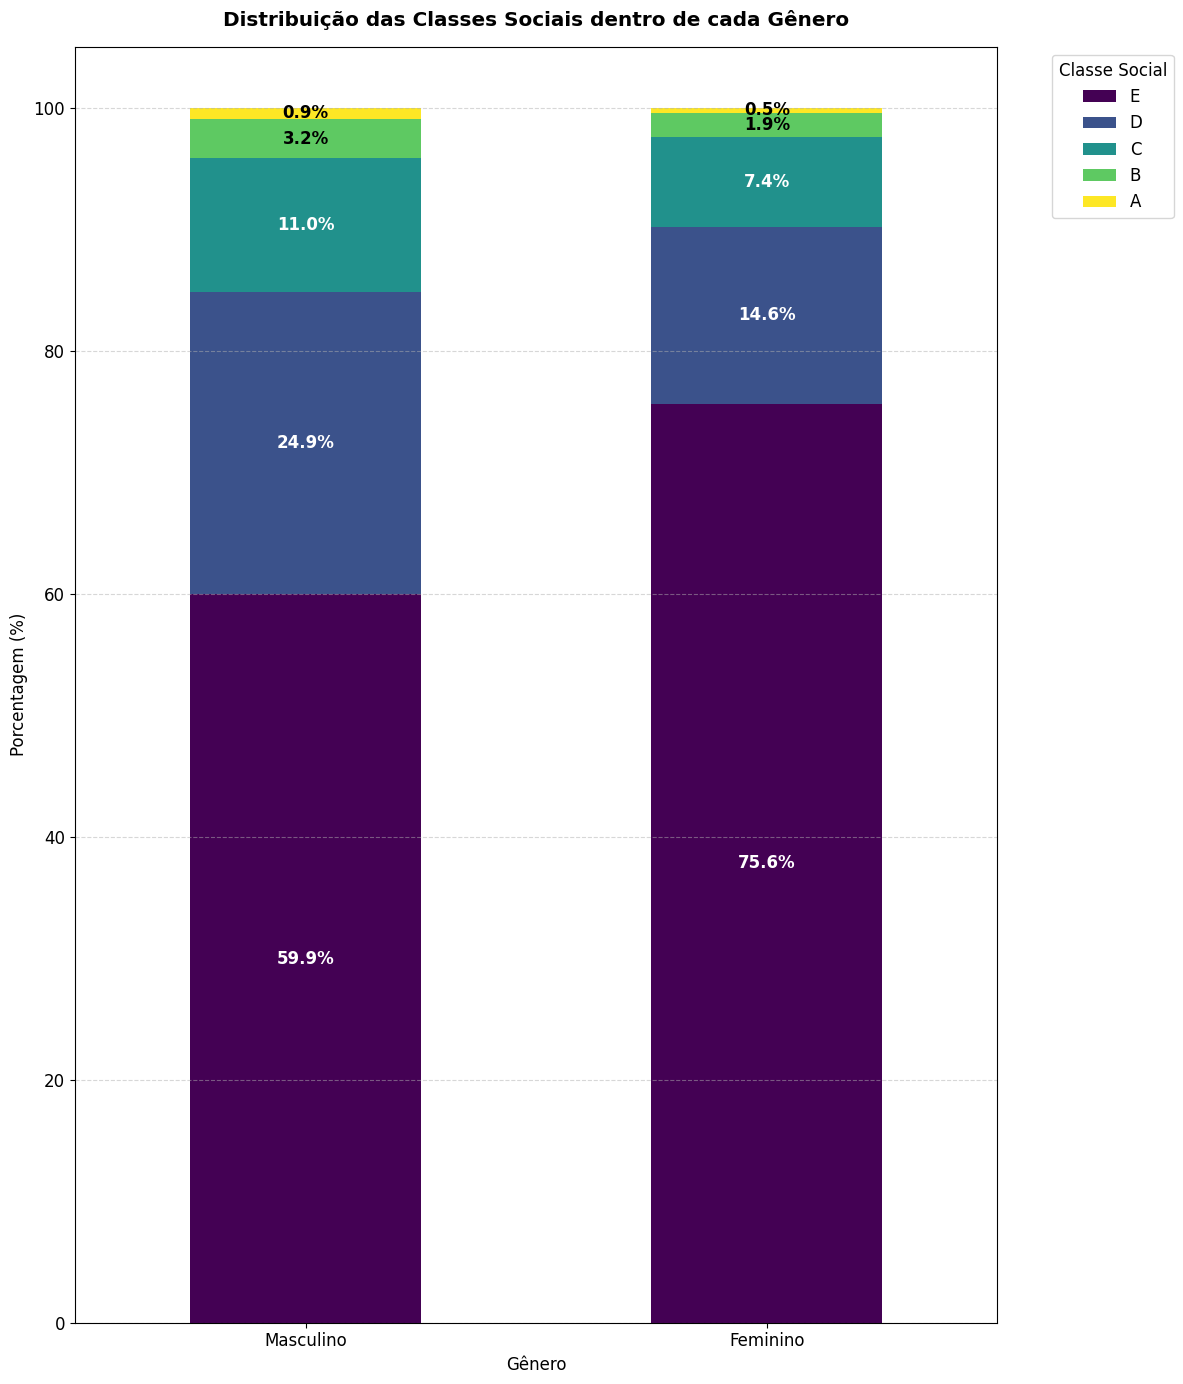

In [74]:
import matplotlib.pyplot as plt

# Garante que os gráficos usem os dados calculados anteriormente
# Certifique-se de rodar o código anterior para gerar 'pct_linha' e 'pct_coluna'

# Configuração estética geral
plt.rcParams['figure.figsize'] = (12, 14)
plt.rcParams['font.size'] = 12

# ----------------------------------------------------
# GRÁFICO 1: Perfil de cada Gênero (Baseado na tabela por linha)
# ----------------------------------------------------
# Inverte a ordem das colunas para exibir de 'A' até 'E' na legenda (se necessário)
ax1 = pct_linha.plot(kind='bar', stacked=True, colormap='viridis')

plt.title('Distribuição das Classes Sociais dentro de cada Gênero', fontweight='bold', pad=15)
plt.xlabel('Gênero')
plt.ylabel('Porcentagem (%)')
plt.xticks(rotation=0)
plt.legend(title='Classe Social', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adiciona rótulos de texto com os valores dentro das barras
for i, c in enumerate(ax1.containers):
    current_class = pct_linha.columns[i]
    label_color = 'black' if current_class in ['A', 'B'] else 'white'
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 0.1 else '' for v in c]
    ax1.bar_label(c, labels=labels, label_type='center', color=label_color, fontweight='bold')

plt.tight_layout()
plt.show()

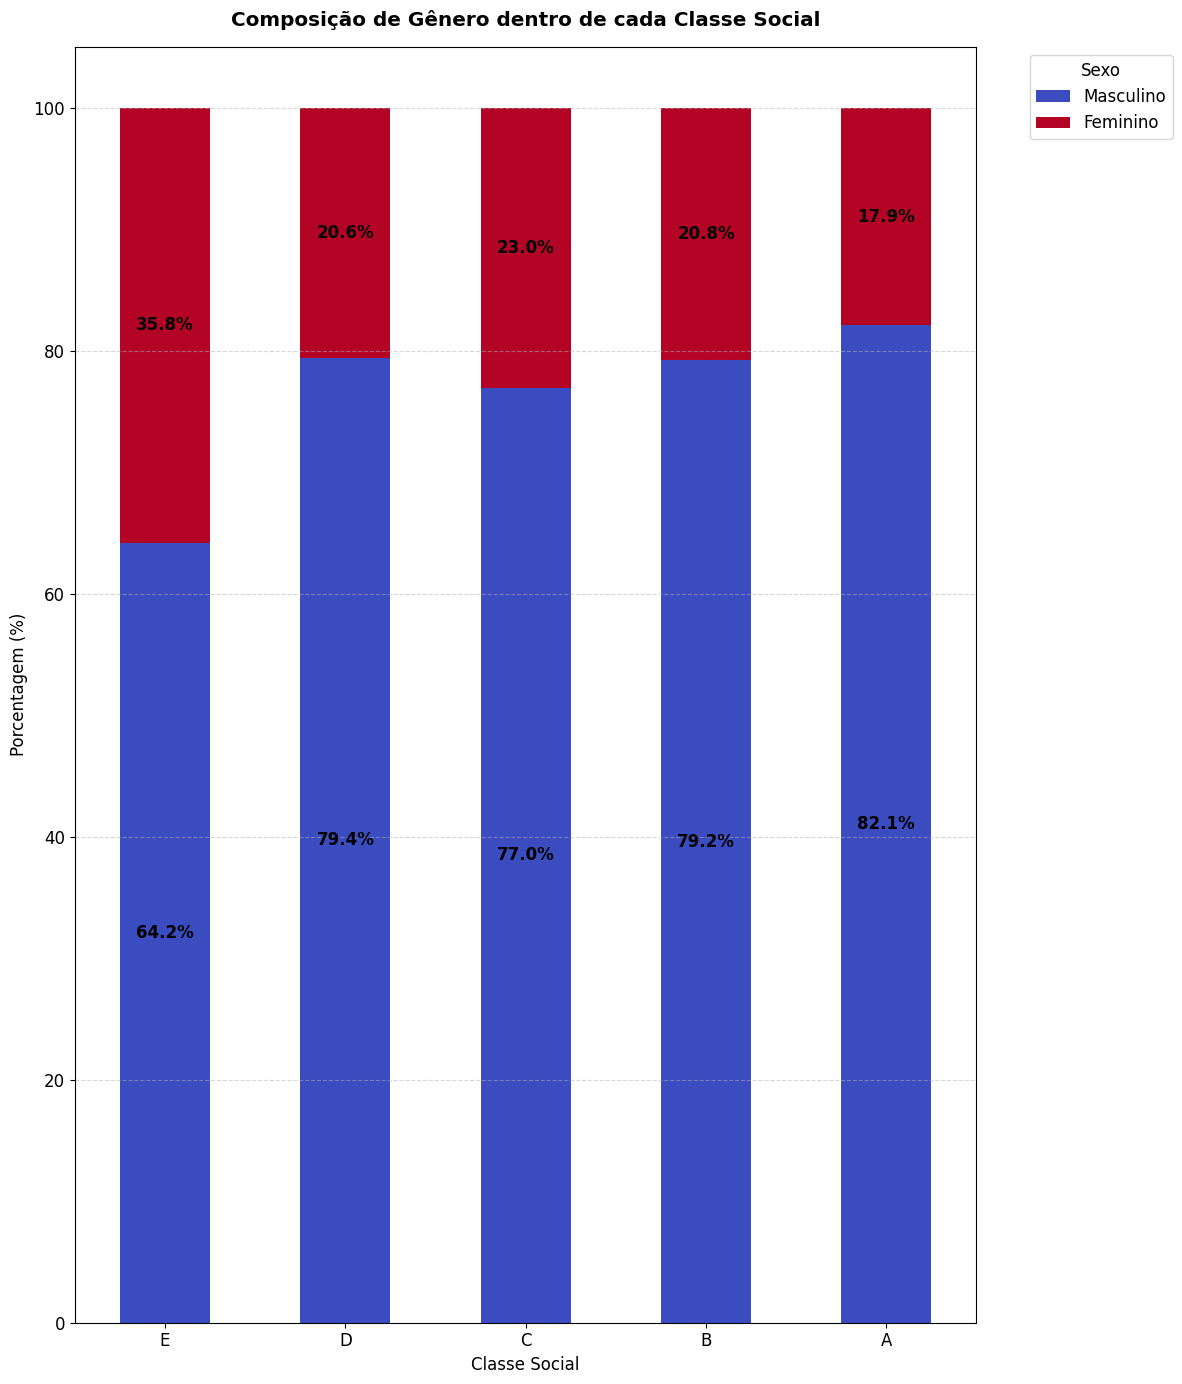

In [75]:
# ----------------------------------------------------
# GRÁFICO 2: Composição de cada Classe (Baseado na tabela por coluna)
# ----------------------------------------------------
# Transpomos (.T) para que as classes fiquem no eixo X
ax2 = pct_coluna.T.plot(kind='bar', stacked=True, colormap='coolwarm')

plt.title('Composição de Gênero dentro de cada Classe Social', fontweight='bold', pad=15)
plt.xlabel('Classe Social')
plt.ylabel('Porcentagem (%)')
plt.xticks(rotation=0)
plt.legend(title='Sexo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Adiciona rótulos de texto com os valores dentro das barras
for c in ax2.containers:
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 2 else '' for v in c]
    ax2.bar_label(c, labels=labels, label_type='center', color='black', fontweight='bold')

plt.tight_layout()
plt.show()

### Gráfico de Pizza das Classes

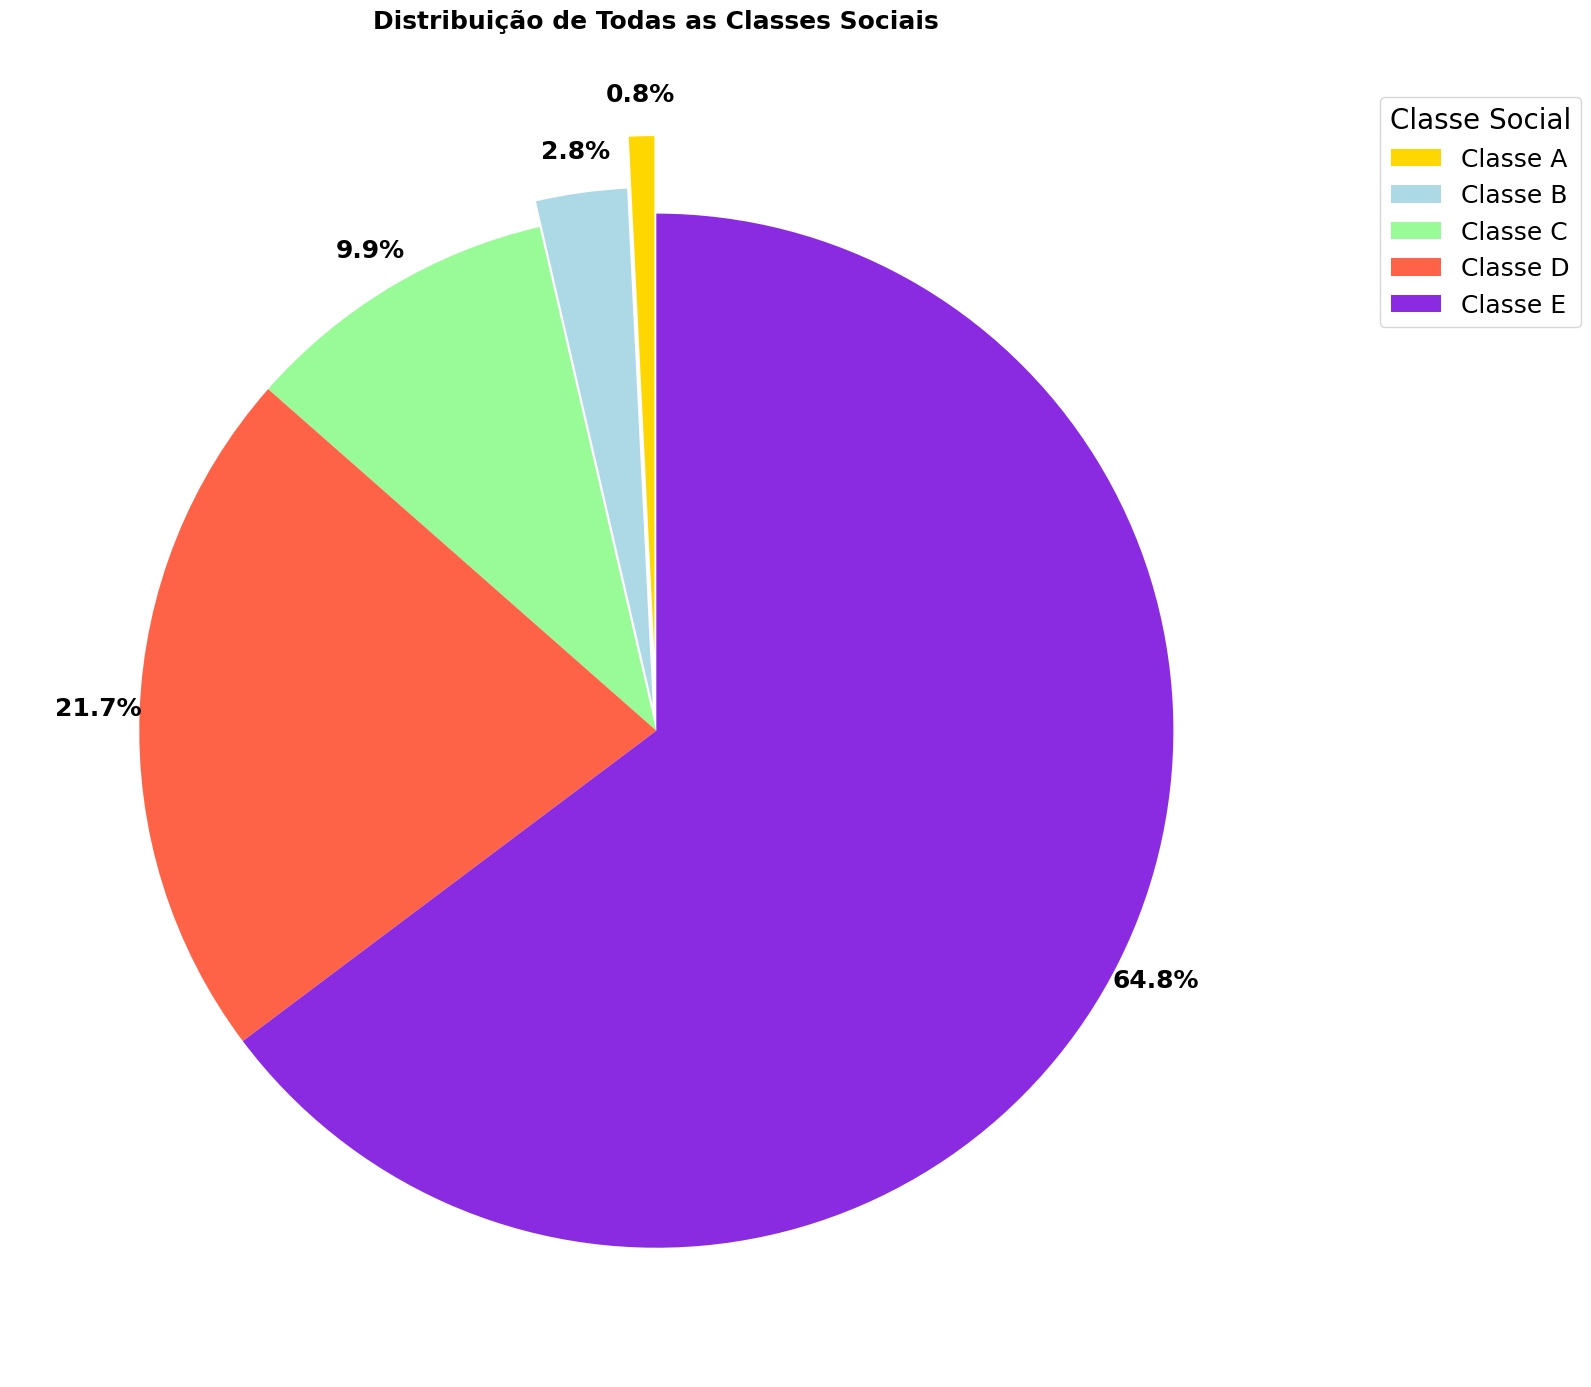

In [76]:
import matplotlib.pyplot as plt

# Usar o DataFrame já existente com todas as classes
# dist_freq_quant_personalizadas já contém 'Frequencia' e 'Porcentagem (%)' para todas as classes A-E

# Garantir que o índice seja 'Classe Social' e que as classes estejam na ordem correta (A-E)
# Se dist_freq_quant_personalizadas não estiver ordenada de A a E, vamos garantir isso.
# Ela já está ordenada de A a E por padrão, mas é bom verificar.

percentual_todas_classes = dist_freq_quant_personalizadas['Porcentagem (%) ']

# Criar o gráfico de pizza
fig, ax = plt.subplots(figsize=(16, 16)) # Aumentar o tamanho do gráfico para mais espaço

# Definir cores para as 5 classes (A a E)
cores = ['#FFD700', '#ADD8E6', '#98FB98', '#FF6347', '#8A2BE2'] # Ex: Amarelo, Azul Claro, Verde Claro, Vermelho, Roxo

# Explodir ligeiramente as fatias menores (Classe A e Classe B) para criar mais espaço
# A ordem das classes em percentual_todas_classes é A, B, C, D, E (devido ao sort_index(ascending=False))
explode = [0.15, 0.05, 0, 0, 0] # Explosão de 5% para A e B

wedges, texts, autotexts = ax.pie(percentual_todas_classes,
                                  # Removendo labels diretamente do pie chart para usar legenda
                                  autopct='%1.1f%%',
                                  startangle=90,
                                  colors=cores,
                                  pctdistance=1.08,     # Colocar as porcentagens fora das fatias
                                  explode=explode)      # Aplicar a explosão

# Adicionar título
ax.set_title("Distribuição de Todas as Classes Sociais", fontsize=18, fontweight='bold', pad=40) # Aumentar o padding

# Melhorar a visibilidade dos rótulos de porcentagem (agora fora das fatias)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(18)
    autotext.set_fontweight('bold')

# Adicionar legenda para as classes
legend_labels = percentual_todas_classes.index.map(lambda x: f'Classe {x}')
ax.legend(wedges, legend_labels, title='Classe Social', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=18, title_fontsize=20)

plt.tight_layout()
plt.show()

## <font color=green>2.4 Histograma</font>
***

O <b>HISTOGRAMA</b> é a representação gráfica de uma distribuição de frequências. É uma gráfico formado por um conjunto de retângulos colocados lado a lado, onde a área de cada retângulo é proporcional à frequência da classe que ele representa.

### Importando a biblioteca

https://seaborn.pydata.org/

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

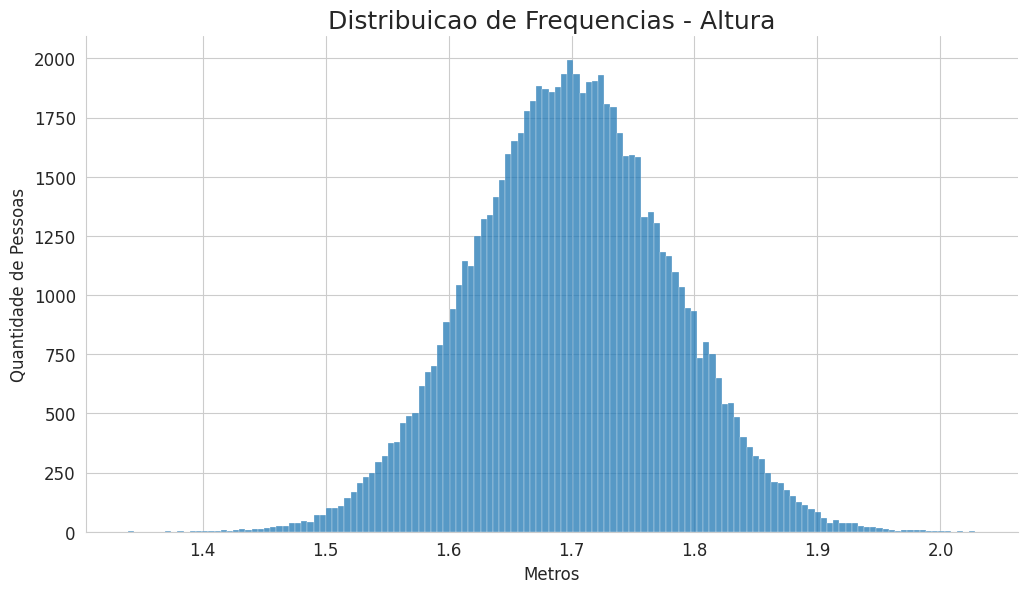

In [78]:
sns.set_style("whitegrid")

ax = sns.displot(dados.Altura, kind='hist')
ax.figure.set_size_inches(12, 6)
ax.set(title='Distribuição de Frequências - Altura', xlabel='Metros', ylabel='Quantidade de Pessoas')

plt.title('Distribuicao de Frequencias - Altura', fontsize=18);

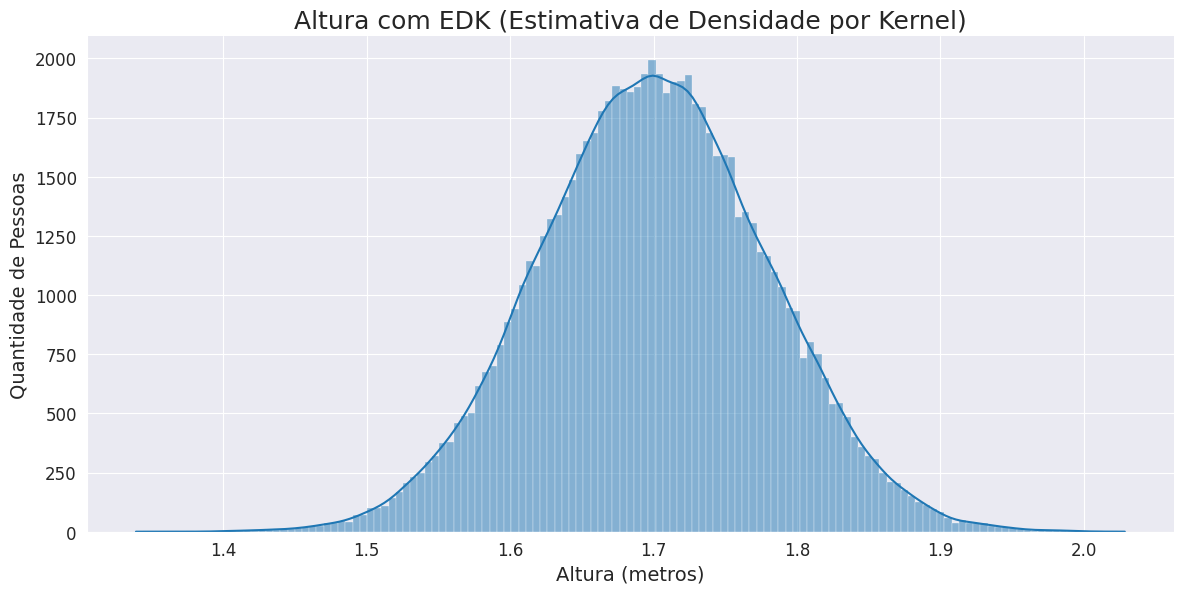

In [79]:
sns.set_style("darkgrid")

ax = sns.displot(dados.Altura, kde=True)
ax.figure.set_size_inches(14, 6)
ax.set_xlabels('Altura (metros)', fontsize=14)
ax.set_ylabels('Quantidade de Pessoas', fontsize=14)

plt.title('Altura com EDK (Estimativa de Densidade por Kernel)', fontsize=18);

<Axes: >

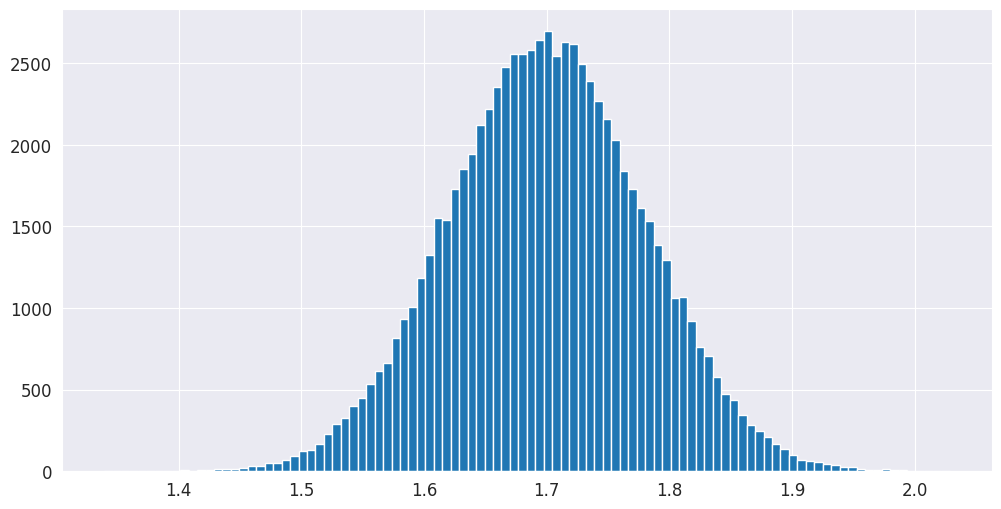

In [80]:
dados.Altura.hist(bins = 100, figsize = (12, 6))

<Axes: xlabel='Classe Social'>

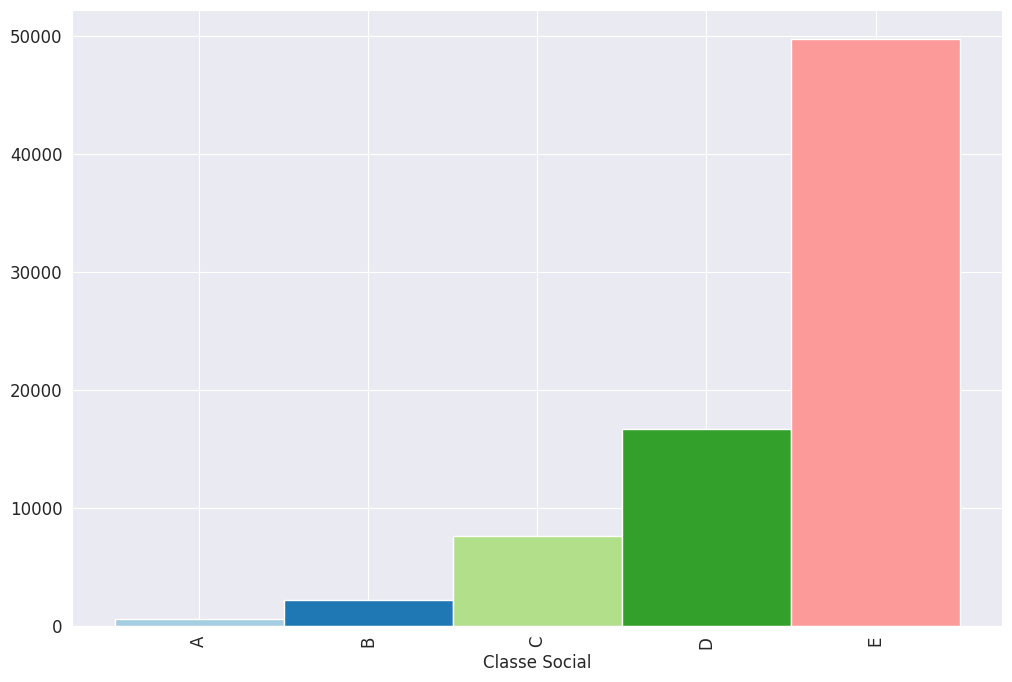

In [81]:
dist_freq_quant_personalizadas['Frequência'].plot.bar(width=1,
                                                      figsize=(12, 8),
                                                      color=plt.cm.Paired(np.arange(len(dist_freq_quant_personalizadas))))

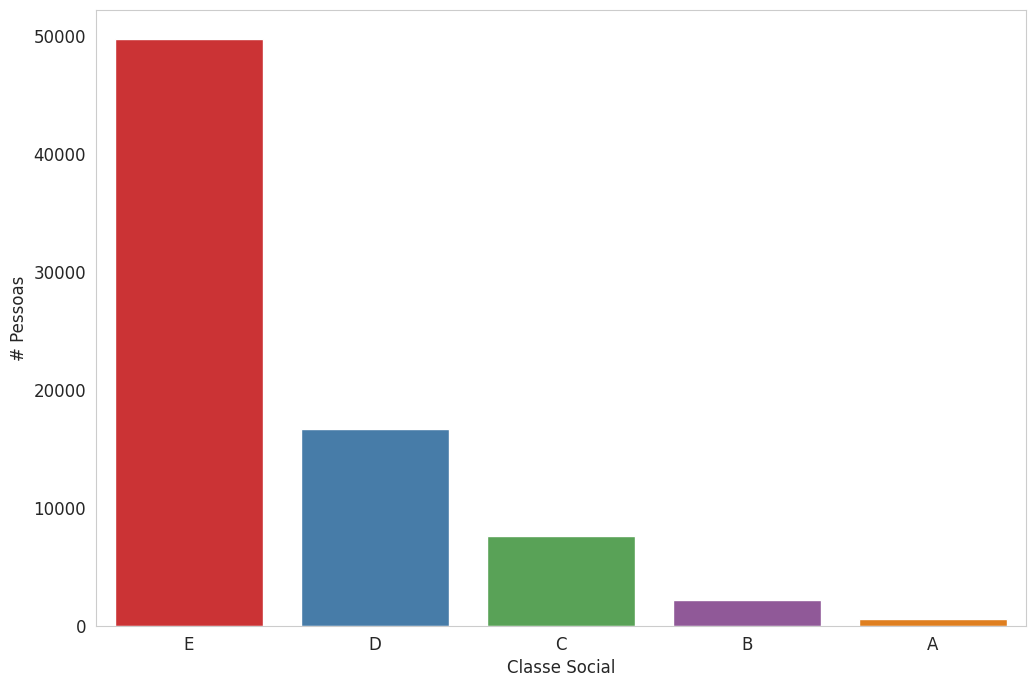

In [82]:
sns.set_style("whitegrid", {'axes.grid' : False})
valores = dist_freq_quant_personalizadas['Frequência']
plt.figure(figsize=(12, 8))

grafico = sns.barplot(x=valores.index, y=valores.values, hue=valores.index, palette='Set1', legend=False)
grafico.set(ylabel='# Pessoas');

# <font color=green>3 MEDIDAS DE TENDÊNCIA CENTRAL</font>
***

## DataFrame de exemplo

In [83]:
df = pd.DataFrame(data = {
    'Fulano': [8, 10, 4, 8, 6, 10, 8],
    'Beltrano': [10, 2, 0.5, 1, 3, 9.5, 10],
    'Sicrano': [7.5, 8, 7, 8, 8, 8.5, 7]
},
    index = ['Matemática', 'Português', 'Inglês', 'Geografia', 'História', 'Física', 'Química']
)
df.rename_axis('Matérias', axis = 'columns', inplace = True)
df

Matérias,Fulano,Beltrano,Sicrano
Matemática,8,10.0,7.5
Português,10,2.0,8.0
Inglês,4,0.5,7.0
Geografia,8,1.0,8.0
História,6,3.0,8.0
Física,10,9.5,8.5
Química,8,10.0,7.0


## <font color=green>3.1 Média aritmética</font>
***

É representada por $\mu$ quando se refere à população e por $\bar{X}$ quando se refere à amostra

# $$\mu = \frac 1n\sum_{i=1}^{n}X_i$$

onde

$n$ = número de observações (registros)

$X_i$ = valor da i-ésima observação (registro)

In [84]:
(8 + 10 + 4 + 8 + 6 + 10 + 8) / 7

df['Fulano'].mean()

dados['Renda'].mean()

2000.3831988547631

In [85]:
dados.head()

,UF,Sexo,Idade,Cor,Anos de Estudo,Renda,Altura
0,11,0,23,8,12,800,1.603808
1,11,1,23,2,12,1150,1.739790
2,11,1,35,8,15,880,1.760444
3,11,0,46,2,6,3500,1.783158
4,11,1,47,8,9,150,1.690631


In [86]:
dados.groupby(['Sexo'])['Renda'].mean()

,Renda
Sexo,
0,2192.441596
1,1566.847393


### Exercício:
Obtenha a média aritmética da idade do ```DataFrame``` *abaixo*:

In [87]:
dataset = pd.DataFrame({
    'Sexo': ['H', 'M', 'M', 'M', 'M', 'H', 'H', 'H', 'M', 'M'],
    'Idade': [53, 72, 54, 27, 30, 40, 58, 32, 44, 51]
})

dataset.mean(numeric_only = True)
dataset['Idade'].mean()

46.1

Com o mesmo DataFrame calcule agora a média somente dos homens:

In [88]:
dataset.groupby(['Sexo']).mean()

,Idade
Sexo,
H,45.750000
M,46.333333


In [89]:
dataset.groupby(['Sexo']).mean().loc['H']

,H
Idade,45.75


## <font color=green>3.2 Mediana</font>
***

Para obtermos a mediana de uma conjunto de dados devemos proceder da seguinte maneira:
1. Ordenar o conjunto de dados;
2. Identificar o número de observações (registros) do conjunto de dados ($n$);
3. Identificar o elemento mediano:

> Quando $n$ for ímpar, a posição do elemento mediano será obtida da seguinte forma:


# $$Elemento_{Md} = \frac{n+1}2$$

> Quando $n$ for par, a posição do elemento mediano será obtida da seguinte forma:


# $$Elemento_{Md} = \frac{n}2$$

4. Obter a mediana:

> Quando $n$ for ímpar:


# $$Md = X_{Elemento_{Md}}$$

> Quando $n$ for par:


# $$Md = \frac{X_{Elemento_{Md}} + X_{Elemento_{Md}+1}}2$$
***

### Exemplo 1 - n ímpar

<img src='https://caelum-online-public.s3.amazonaws.com/1177-estatistica-parte1/01/img002.png' width='40%' style="float:left">

In [90]:
notas_fulano = df.Fulano
notas_fulano

,Fulano
Matemática,8
Português,10
Inglês,4
Geografia,8
História,6
Física,10
Química,8


In [91]:
notas_fulano = notas_fulano.sort_values()
notas_fulano

,Fulano
Inglês,4
História,6
Geografia,8
Matemática,8
Química,8
Português,10
Física,10


In [92]:
notas_fulano = notas_fulano.reset_index()
notas_fulano

,index,Fulano
0,Inglês,4
1,História,6
2,Geografia,8
3,Matemática,8
4,Química,8
5,Português,10
6,Física,10


In [93]:
n = notas_fulano.shape[0]
n

7

In [94]:
elemento_md = (n+1) / 2
elemento_md

4.0

In [95]:
notas_fulano.loc[elemento_md - 1]

,3
index,Matemática
Fulano,8


In [96]:
notas_fulano

,index,Fulano
0,Inglês,4
1,História,6
2,Geografia,8
3,Matemática,8
4,Química,8
5,Português,10
6,Física,10


In [97]:
#1a forma
print(notas_fulano.Fulano.median())

8.0


In [98]:
#2a forma
print(notas_fulano['Fulano'].median())

8.0


### Exemplo 2 - n par

<img src='https://caelum-online-public.s3.amazonaws.com/1177-estatistica-parte1/01/img003.png' width='50%' style="float:left">

In [99]:
notas_beltrano = df.Beltrano.sample(6, random_state = 42)
notas_beltrano

,Beltrano
Matemática,10.0
Português,2.0
Física,9.5
Inglês,0.5
História,3.0
Geografia,1.0


In [100]:
notas_beltrano = notas_beltrano.sort_values()
notas_beltrano

,Beltrano
Inglês,0.5
Geografia,1.0
Português,2.0
História,3.0
Física,9.5
Matemática,10.0


In [101]:
notas_beltrano = notas_beltrano.reset_index()
notas_beltrano


,index,Beltrano
0,Inglês,0.5
1,Geografia,1.0
2,Português,2.0
3,História,3.0
4,Física,9.5
5,Matemática,10.0


In [102]:
n = notas_beltrano.shape[0]

In [103]:
meio = int(n / 2) -1
meio

2

Cálculo manual da mediana:

In [104]:
# Acessa elementos individuais do DataFrame com iloc[] atraves de sua posicao
elemento_md1 = notas_beltrano.iloc[meio, 1]
elemento_md2 = notas_beltrano.iloc[meio + 1, 1]

print(f'Elemento 1:\n{elemento_md1}\n\nElemento 2:\n{elemento_md2}\n')

mediana = (elemento_md1 + elemento_md2) / 2
print('Mediana:', mediana)

Elemento 1:
2.0

Elemento 2:
3.0

Mediana: 2.5


In [105]:
#Recupera a coluna das notas
notas_beltrano.iloc[:, 1]

,Beltrano
0,0.5
1,1.0
2,2.0
3,3.0
4,9.5
5,10.0


Cálculo usando função de biblioteca:

In [106]:
#Mediana da Coluna notas (média das disciplinas) usando a função median ()
print('Mediana:', notas_beltrano.iloc[:, 1].median())

Mediana: 2.5


### Obtendo a mediana em nosso dataset

Calculando a mediana da coluna `Renda`:

In [107]:
dados.Renda.median()

1200.0

Por padrão, o método `quantile()` calcula o quantil de 50%, o que corresponde à mediana:

In [108]:
print(dados.Renda.quantile())

1200.0


## <font color=green>3.3 Moda</font>
***

Pode-se definir a moda como sendo o valor mais frequente de um conjunto de dados. A moda é bastante utilizada para dados qualitativos.

In [109]:
df

Matérias,Fulano,Beltrano,Sicrano
Matemática,8,10.0,7.5
Português,10,2.0,8.0
Inglês,4,0.5,7.0
Geografia,8,1.0,8.0
História,6,3.0,8.0
Física,10,9.5,8.5
Química,8,10.0,7.0


In [110]:
df.mode()

Matérias,Fulano,Beltrano,Sicrano
0,8,10.0,8.0


In [111]:
pd.Series([1,2,2,3,4,4,5,6,6])

,0
0,1
1,2
2,2
3,3
4,4
5,4
6,5
7,6
8,6


In [113]:
df.mode()

Matérias,Fulano,Beltrano,Sicrano
0,8,10.0,8.0


### Obtendo a moda em nosso *dataset*:

In [114]:
#O Resultado é o código 35, que é São Paulo
dados.UF.mode()

,UF
0,35


## <font color=green>3.4 Relação entre média, mediana e moda</font>
***

<img src='https://caelum-online-public.s3.amazonaws.com/1177-estatistica-parte1/01/img004.png' width='80%'>

### Avaliando a variável RENDA

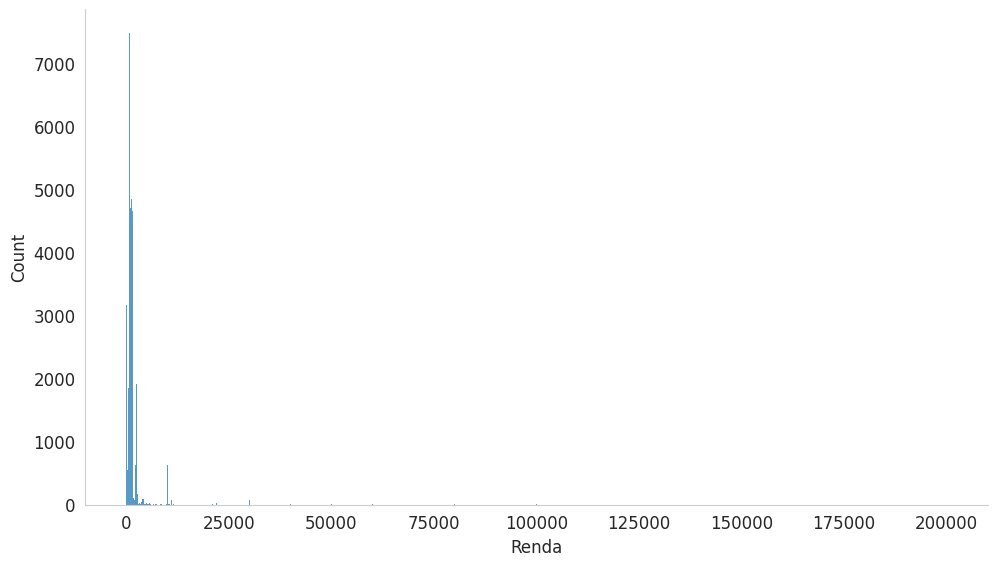

In [115]:
ax = sns.displot(dados.Renda)
ax.figure.set_size_inches(12, 6)

<Axes: xlabel='Renda', ylabel='Density'>

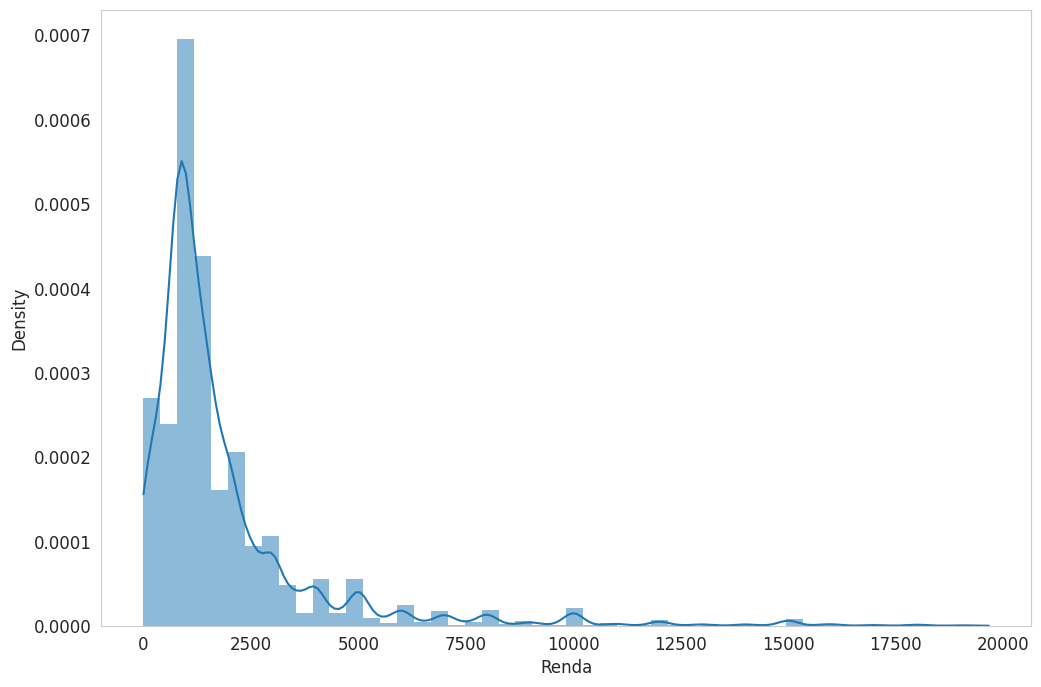

In [116]:
ax = sns.histplot(dados.query('Renda < 20000').Renda, stat="density", element="step", bins=50, kde=True, lw=0)
ax.figure.set_size_inches(12, 8)
ax

In [117]:
moda = dados.Renda.mode()[0]
print(moda)

788


In [118]:
mediana = dados.Renda.median()
mediana

1200.0

In [119]:
medi = dados.Renda.mean()
print(medi)

2000.3831988547631


In [121]:
print(moda < mediana < medi)

True


### Avaliando a variável ALTURA

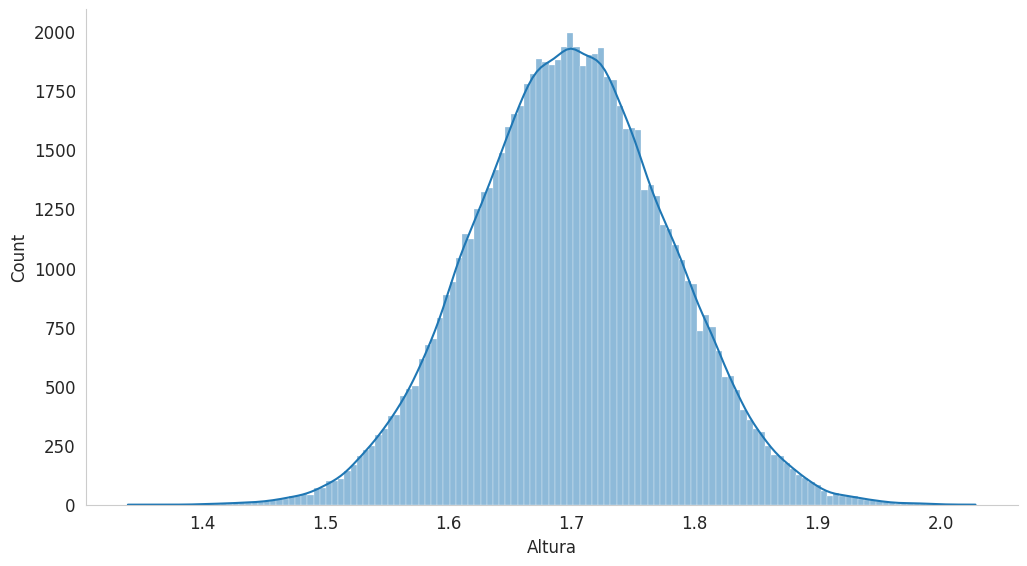

In [122]:
ax= sns.displot(dados.Altura, kde = True)
ax.figure.set_size_inches(12, 6)
ax

In [123]:
moda = dados.Altura.mode()
moda


,Altura
0,1.568128
1,1.671225
2,1.681659
3,1.692977
4,1.708163
5,1.708370
6,1.753842
7,1.779073
8,1.796462


In [124]:
mediana = dados.Altura.median()
mediana

1.6993247325

In [125]:
media = dados.Altura.mean()
media

1.6995124540575741

***

### Avaliando a variável ANOS DE ESTUDO

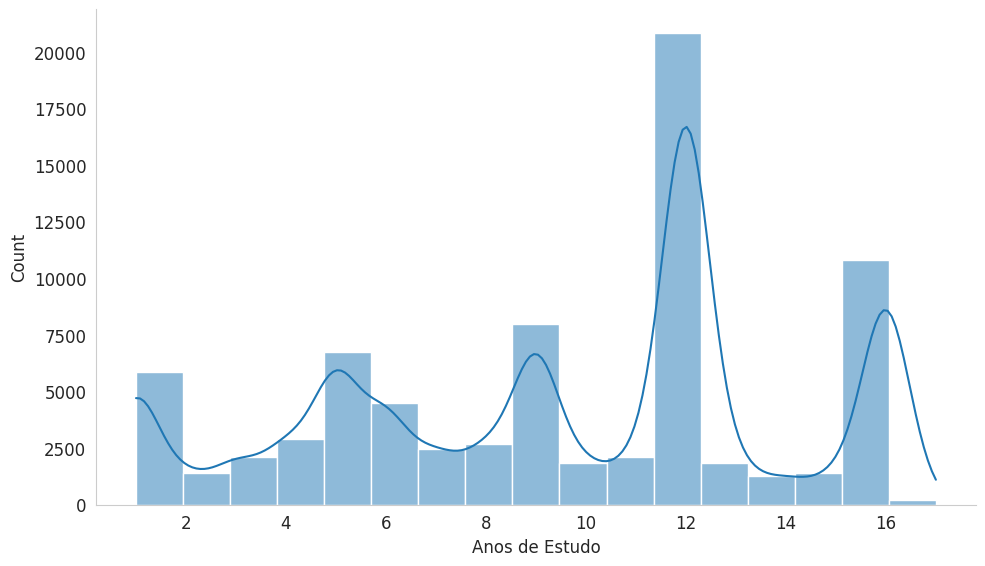

In [126]:
ax = sns.displot(dados['Anos de Estudo'], bins = 17, kde = True)
ax.figure.set_size_inches(12, 6)
ax

In [127]:
moda = dados ['Anos de Estudo'].mode()[0]
print(moda)

12


In [128]:
mediana=dados['Anos de Estudo'].median()
print(mediana)

11.0


In [129]:
media = dados['Anos de Estudo'].mean()
print(media)

9.469664237376367


In [130]:
print(moda < mediana < media)

False


# <font color=green>4 MEDIDAS SEPARATRIZES</font>
***

## <font color=green>4.1 Quartis, decis e percentis</font>
***

Há uma série de medidas de posição semelhantes na sua concepção à mediana, embora não sejam medidas de tendência central. Como se sabe, a mediana divide a distribuição em duas partes iguais quanto ao número de elementos de cada parte. Já os quartis permitem dividir a distribuição em quatro partes iguais quanto ao número de elementos de cada uma; os decis em dez partes e os centis em cem partes iguais.

In [131]:
dados.Renda.median(), dados.Renda.quantile(), dados.Renda.quantile(q=0.5)

(1200.0, 1200.0, 1200.0)

In [132]:
dados.Renda.quantile([.25, .5, .75])

,Renda
0.25,788.0
0.50,1200.0
0.75,2000.0


In [ ]:
[i/10 for i in range(1, 10)]

Exemplo de utilização de [compreensão de listas em Python](https://pythonacademy.com.br/blog/list-comprehensions-no-python) a fim de montar uma lista com os decis (divisão em 10 partes):

In [133]:
dados.Renda.quantile([i/10 for i in range(1, 11)])

,Renda
0.1,350.0
0.2,788.0
0.3,800.0
0.4,1000.0
0.5,1200.0
0.6,1500.0
0.7,1900.0
0.8,2500.0
0.9,4000.0
1.0,200000.0


In [134]:
dados.Idade.median()

43.0

In [135]:
dados.Idade.quantile([i/10 for i in range(1, 11)])

,Idade
0.1,28.0
0.2,33.0
0.3,36.0
0.4,40.0
0.5,43.0
0.6,47.0
0.7,51.0
0.8,55.0
0.9,61.0
1.0,99.0


In [136]:
print(f"Número de observações:\n{dados.Idade.count()}\n")
print(f"Menor idade:\n{dados.Idade.min()}\n\nMaior idade:\n{dados.Idade.max()}\n")
stats_df = dados.groupby('Idade')['Idade'].agg('count')
stats_df

Número de observações:
76840

Menor idade:
13

Maior idade:
99



,Idade
Idade,
13,1
14,1
15,6
16,10
17,49
...,...
92,3
94,1
95,1


In [137]:
stats_df.cumsum()

,Idade
Idade,
13,1
14,2
15,8
16,18
17,67
...,...
92,76836
94,76837
95,76838


In [138]:
dados.groupby(pd.cut(dados.Idade, 10))['Idade'].count()

/tmp/ipykernel_553/2580583996.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dados.groupby(pd.cut(dados.Idade, 10))['Idade'].count()


,Idade
Idade,
"(12.914, 21.6]",1212
"(21.6, 30.2]",10144
"(30.2, 38.8]",16522
"(38.8, 47.4]",19065
"(47.4, 56.0]",16927
"(56.0, 64.6]",8648
"(64.6, 73.2]",3283
"(73.2, 81.8]",864
"(81.8, 90.4]",161


In [139]:
cs = dados.groupby(pd.cut(dados.Idade, 10), observed=False) ['Idade'].count().cumsum()
cs

,Idade
Idade,
"(12.914, 21.6]",1212
"(21.6, 30.2]",11356
"(30.2, 38.8]",27878
"(38.8, 47.4]",46943
"(47.4, 56.0]",63870
"(56.0, 64.6]",72518
"(64.6, 73.2]",75801
"(73.2, 81.8]",76665
"(81.8, 90.4]",76826


In [140]:
100 * (cs / dados.Idade.count())

,Idade
Idade,
"(12.914, 21.6]",1.577303
"(21.6, 30.2]",14.778761
"(30.2, 38.8]",36.280583
"(38.8, 47.4]",61.091879
"(47.4, 56.0]",83.120770
"(56.0, 64.6]",94.375325
"(64.6, 73.2]",98.647840
"(73.2, 81.8]",99.772254
"(81.8, 90.4]",99.981780


In [141]:
#divide as idades em 10 intervalos (bins) iguais
intervalos = pd.cut(dados.Idade, bins=10)

#calcula a frequência relativa (normalize=True) ordenada pelos intervalos e acumula (.cumsum())
tabela_proporcao = intervalos.value_counts(sort=False, normalize=True).cumsum()

#exibe o resultado
print(tabela_proporcao)

Idade
(12.914, 21.6]    0.015773
(21.6, 30.2]      0.147788
(30.2, 38.8]      0.362806
(38.8, 47.4]      0.610919
(47.4, 56.0]      0.831208
(56.0, 64.6]      0.943753
(64.6, 73.2]      0.986478
(73.2, 81.8]      0.997723
(81.8, 90.4]      0.999818
(90.4, 99.0]      1.000000
Name: proportion, dtype: float64


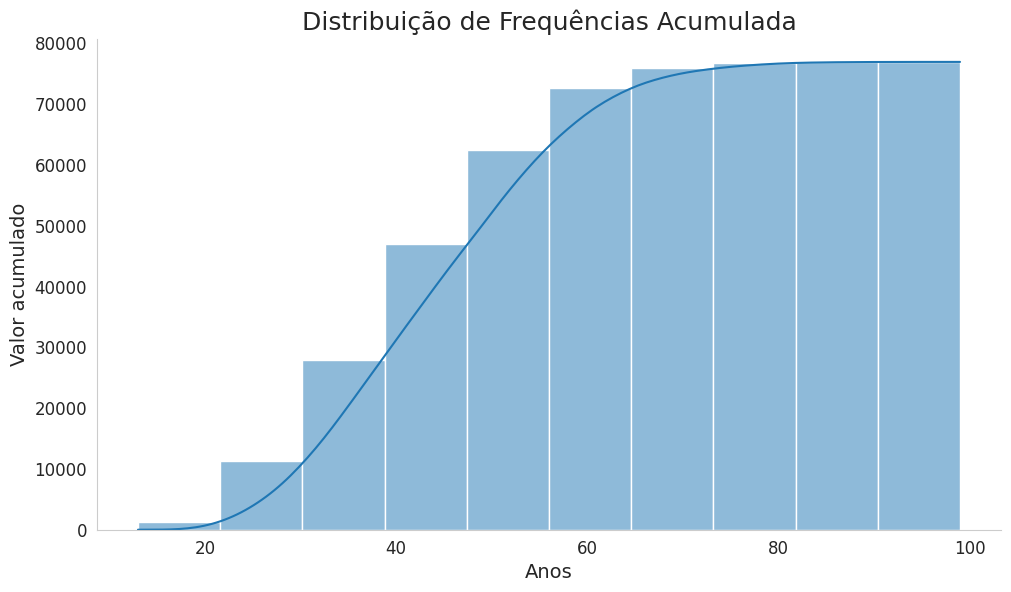

In [142]:
ax = sns.displot(dados.Idade, kde=True, cumulative=True, bins=10, stat='count')
ax.figure.set_size_inches(12, 6)
ax.set_xlabels('Anos', fontsize=14)
ax.set_ylabels('Valor acumulado', fontsize=14);

plt.title('Distribuição de Frequências Acumulada', fontsize=18);

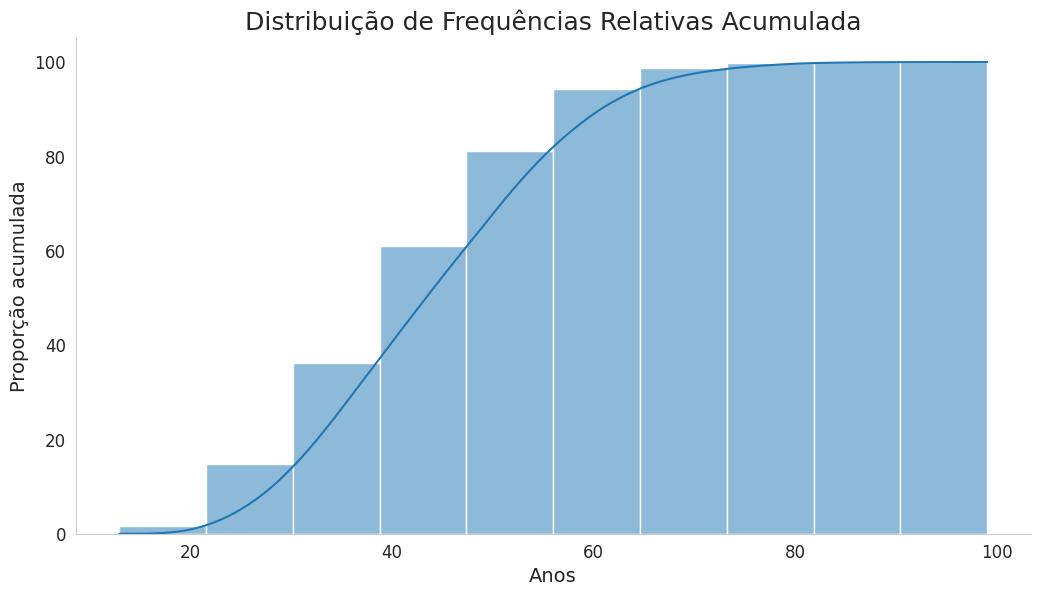

In [143]:
ax = sns.displot(dados.Idade, kde=True, cumulative=True, bins=10, stat='percent')
ax.figure.set_size_inches(12, 6)
ax.set_xlabels('Anos', fontsize=14)
ax.set_ylabels('Proporção acumulada', fontsize=14);

plt.title('Distribuição de Frequências Relativas Acumulada', fontsize=18);

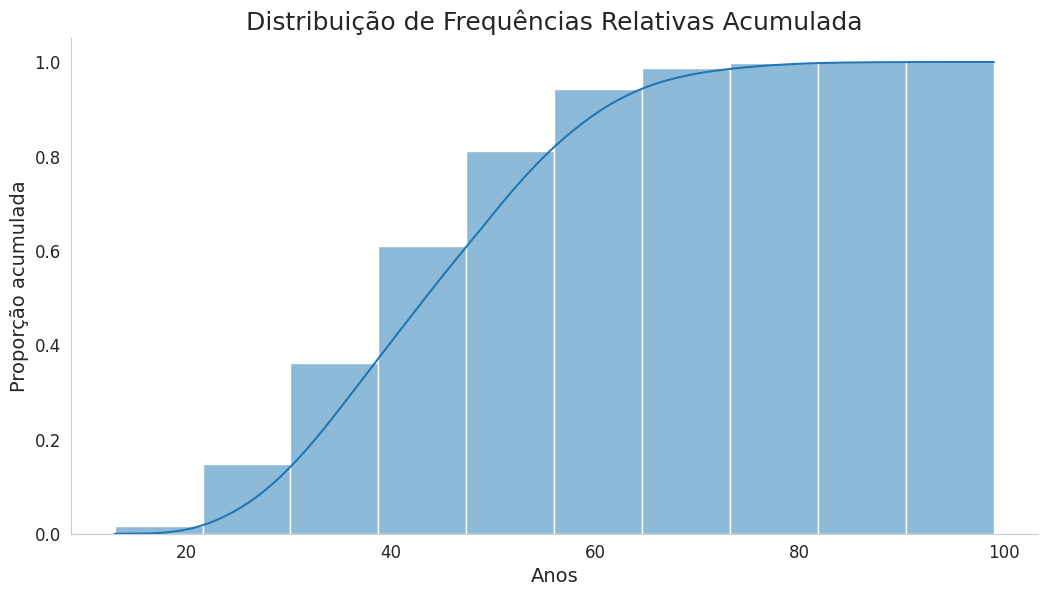

In [144]:
ax = sns.displot(dados.Idade, kde=True, cumulative=True, bins=10, stat='probability')
ax.figure.set_size_inches(12, 6)
ax.set_xlabels('Anos', fontsize=14)
ax.set_ylabels('Proporção acumulada', fontsize=14);

plt.title('Distribuição de Frequências Relativas Acumulada', fontsize=18);

In [145]:
# agrupa os dados nos mesmos 10 intervalos da imagem
intervalos = pd.cut(dados.Idade, bins=10)

#calcula a largura (width) de um intervalo
largura_do_bin = intervalos.cat.categories[0].right - intervalos.cat.categories[0].left
print('Idade mínima:', dados.Idade.min())
print(f'Intervalos {intervalos.cat.categories[0].left} a {intervalos.cat.categories[0].right}')
print(f'Largura do intervalo: {largura_do_bin:.4f}')

#calcula as frequências absolutas (contagem)
contagens = intervalos.value_counts(sort=False)
total_registros = len(dados.Idade)

#Calcula a densidade acumulada matemática (fórmula do Seaborn) | Densidade = contagem / (total * largura)
densidades = contagens / (total_registros * largura_do_bin)
densidade_acumulada = densidades.cumsum()

print(densidade_acumulada)

Idade mínima: 13
Intervalos 12.914 a 21.6
Largura do intervalo: 8.6860
Idade
(12.914, 21.6]    0.001816
(21.6, 30.2]      0.017014
(30.2, 38.8]      0.041769
(38.8, 47.4]      0.070334
(47.4, 56.0]      0.095695
(56.0, 64.6]      0.108652
(64.6, 73.2]      0.113571
(73.2, 81.8]      0.114866
(81.8, 90.4]      0.115107
(90.4, 99.0]      0.115128
Name: count, dtype: float64


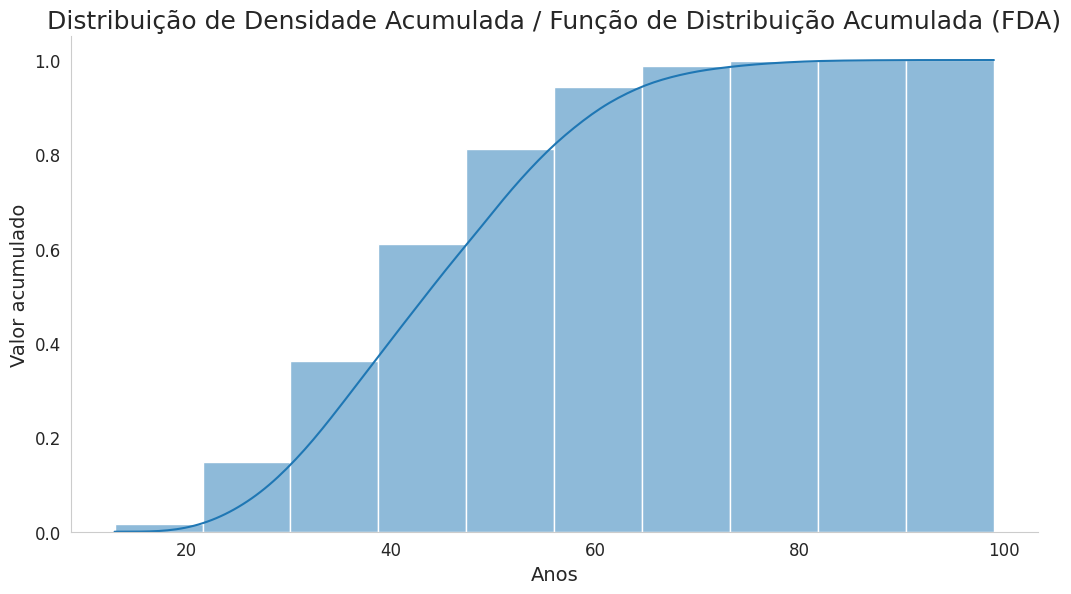

In [146]:
ax = sns.displot(dados.Idade, kde=True, cumulative=True, bins=10, stat='density')
ax.figure.set_size_inches(12, 6)
ax.set_xlabels('Anos', fontsize=14)
ax.set_ylabels('Valor acumulado', fontsize=14);

plt.title('Distribuição de Densidade Acumulada / Função de Distribuição Acumulada (FDA)', fontsize=18);

In [147]:
dados.Renda.quantile([i / 100 for i in range(1, 100)])

,Renda
0.01,0.0
0.02,0.0
0.03,0.0
0.04,50.0
0.05,100.0
...,...
0.95,6000.0
0.96,7000.0
0.97,8000.0
0.98,10000.0


In [148]:
dados.Renda.quantile([i / 100 for i in range(1, 101)])

,Renda
0.01,0.0
0.02,0.0
0.03,0.0
0.04,50.0
0.05,100.0
...,...
0.96,7000.0
0.97,8000.0
0.98,10000.0
0.99,15000.0


## <font color=green>4.2 Box-plot</font>
***

O box plot dá uma idéia da posição, dispersão, assimetria, caudas e dados discrepantes (outliers). A posição central é dada pela mediana e a dispersão por $IIQ$. As posições relativas de $Q1$, $Mediana$ e $Q3$ dão uma noção da simetria da distribuição. Os comprimentos das cauda são dados pelas linhas que vão do retângulo aos valores remotos e pelos valores atípicos.

<img src='https://caelum-online-public.s3.amazonaws.com/1177-estatistica-parte1/01/img005.png' width='65%'>

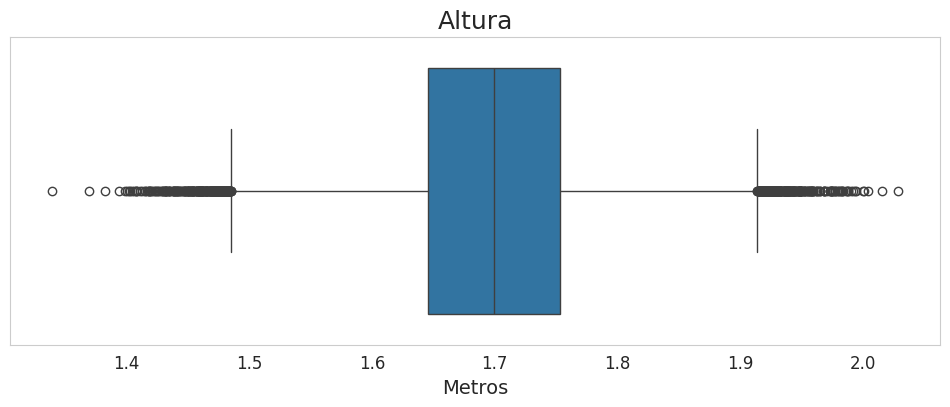

In [149]:
ax = sns.boxplot(x='Altura', data=dados, orient='h')
ax.figure.set_size_inches(12, 4)
plt.title('Altura', fontsize=18)
ax.set_xlabel('Metros', fontsize=14);

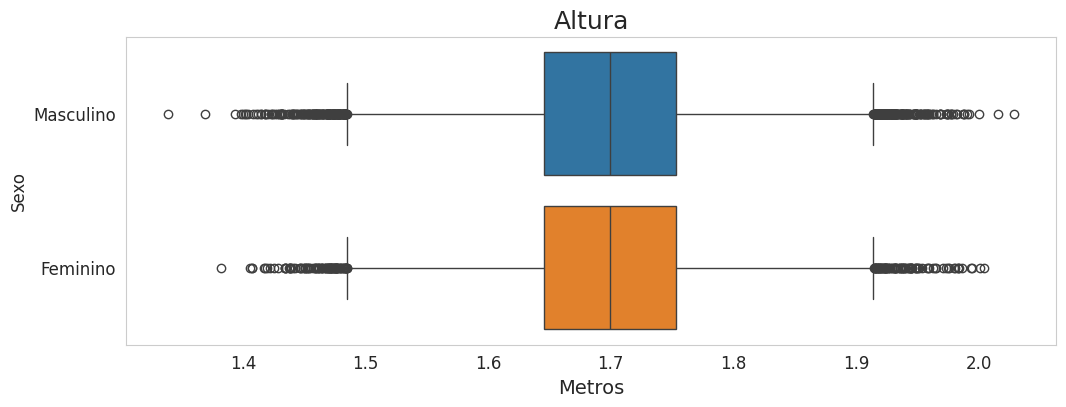

In [150]:
ax = sns.boxplot(x='Altura', y='Sexo', data=dados, orient='h', hue='Sexo', legend=False)

ax.figure.set_size_inches(12, 4)
ax.set_title('Altura', fontsize=18)
ax.set_xlabel('Metros', fontsize=14)
ax.set_yticks([0, 1]) # Define os ticks do eixo Y explicitamente
ax.set_yticklabels(['Masculino', 'Feminino']);

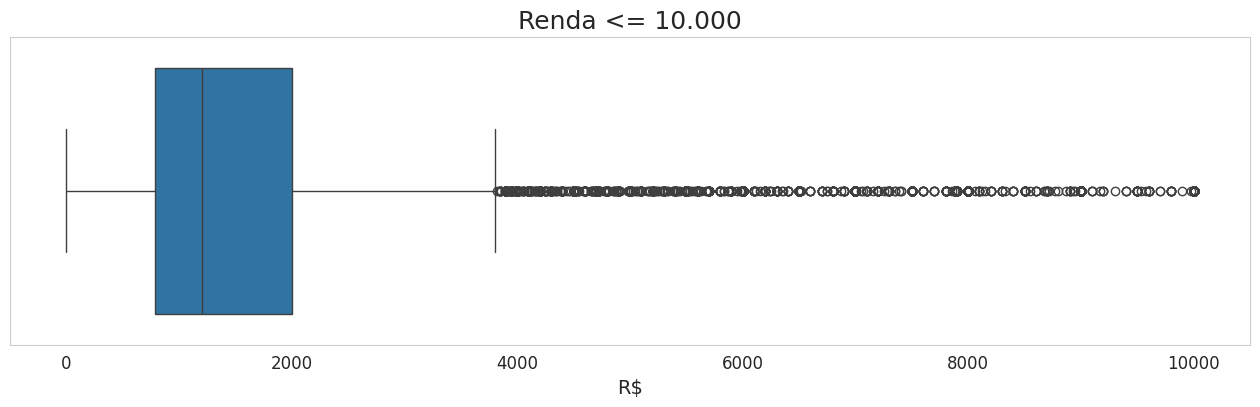

In [151]:
ax = sns.boxplot(x='Renda', data=dados.query('Renda <= 10_000'), orient='h')
ax.figure.set_size_inches(16, 4)
ax.set_title('Renda <= 10.000', fontsize=18)
ax.set_xlabel('R$', fontsize=14);

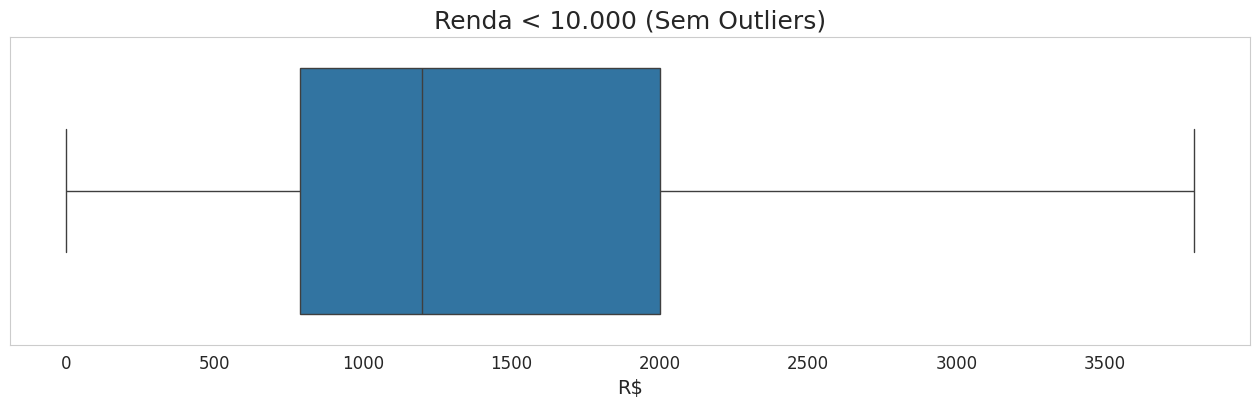

In [152]:
ax = sns.boxplot(x='Renda', data=dados.query('Renda <= 10_000'), orient='h', showfliers=False)
ax.figure.set_size_inches(16, 4)
ax.set_title('Renda < 10.000 (Sem Outliers)', fontsize=18)
ax.set_xlabel('R$', fontsize=14);

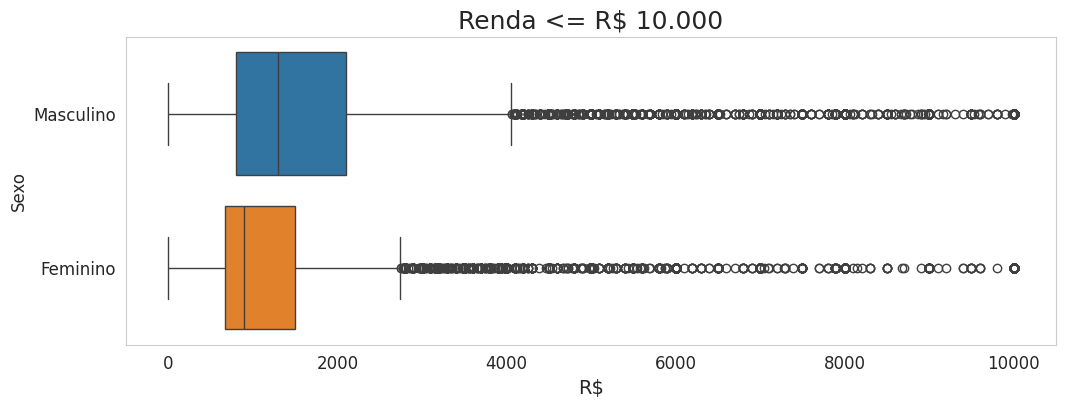

In [153]:
ax = sns.boxplot(x='Renda', y='Sexo', data=dados.query('Renda <= 10_000'), orient='h', hue='Sexo', legend=False)

ax.figure.set_size_inches(12, 4)
ax.set_title('Renda <= R$ 10.000', fontsize=18)
ax.set_xlabel('R$', fontsize=14)
ax.set_yticks([0, 1]) # Define os ticks do eixo Y explicitamente
ax.set_yticklabels(['Masculino', 'Feminino']);

<Axes: title={'center': 'Anos de Estudo'}, xlabel='Anos'>

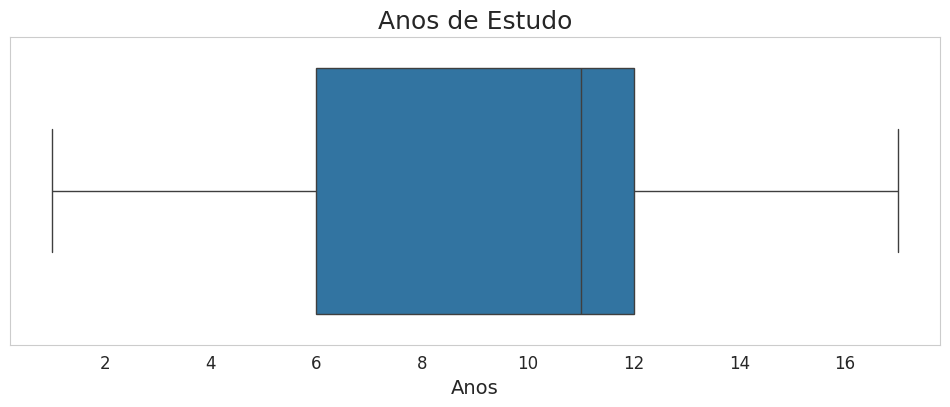

In [154]:
ax = sns.boxplot(x = 'Anos de Estudo', data = dados, orient = 'h')
ax.figure.set_size_inches(12, 4)
ax.set_title('Anos de Estudo', fontsize = 18)
ax.set_xlabel('Anos', fontsize = 14)
ax

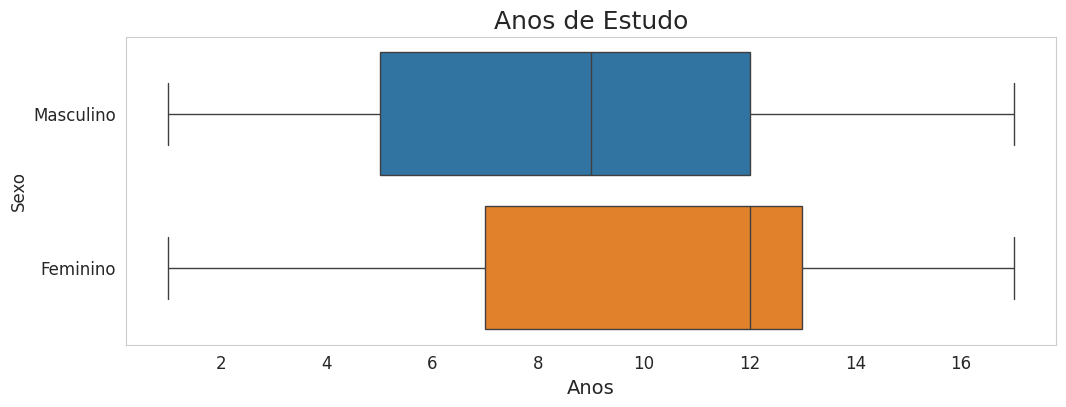

In [155]:
ax = sns.boxplot(x='Anos de Estudo', y='Sexo', data=dados, orient='h', hue='Sexo', legend=False)
ax.figure.set_size_inches(12, 4)
ax.set_title('Anos de Estudo', fontsize=18)
ax.set_xlabel('Anos', fontsize=14)

ax.set_yticks([0, 1])
ax.set_yticklabels(['Masculino', 'Feminino']);

<img src='https://caelum-online-public.s3.amazonaws.com/1177-estatistica-parte1/01/img006.png' width='80%'>

# <font color=green>5 MEDIDAS DE DISPERSÃO</font>
***

Embora as medidas de posição forneçam uma sumarização bastante importante dos dados, elas podem não ser suficientes para caracterizar conjuntos distintos, especialmente quando as observações de determinada distribuição apresentarem dados muito dispersos.

## <font color=green>5.1 Desvio médio absoluto</font>
***


# $$DM = \frac 1n\sum_{i=1}^{n}|X_i-\bar{X}|$$


In [156]:
df

Matérias,Fulano,Beltrano,Sicrano
Matemática,8,10.0,7.5
Português,10,2.0,8.0
Inglês,4,0.5,7.0
Geografia,8,1.0,8.0
História,6,3.0,8.0
Física,10,9.5,8.5
Química,8,10.0,7.0


In [157]:
df.mean()

,0
Matérias,
Fulano,7.714286
Beltrano,5.142857
Sicrano,7.714286


In [158]:
df.median()

,0
Matérias,
Fulano,8.0
Beltrano,3.0
Sicrano,8.0


In [159]:
notas_fulano = df['Fulano']
notas_fulano

,Fulano
Matemática,8
Português,10
Inglês,4
Geografia,8
História,6
Física,10
Química,8


In [160]:
notas_fulano = df[['Fulano']].copy()
notas_fulano

Matérias,Fulano
Matemática,8
Português,10
Inglês,4
Geografia,8
História,6
Física,10
Química,8


In [161]:
nota_media_fulano = notas_fulano.mean().iloc[0]
print(nota_media_fulano)

7.714285714285714


In [162]:
#notass_fulano = notas_fulano.assign(Desvio=notas_fulano['Fulano'] - nota_media_fulano)
notas_fulano.loc[:, 'Desvio'] = (notas_fulano['Fulano'] - nota_media_fulano)
notas_fulano
#notas_fulano['Desvio']

Matérias,Fulano,Desvio
Matemática,8,0.285714
Português,10,2.285714
Inglês,4,-3.714286
Geografia,8,0.285714
História,6,-1.714286
Física,10,2.285714
Química,8,0.285714


In [163]:
int(notas_fulano['Desvio'].sum())

0

In [164]:
notas_fulano.loc[:, '|Desvio|'] = notas_fulano['Desvio'].abs()
notas_fulano

Matérias,Fulano,Desvio,|Desvio|
Matemática,8,0.285714,0.285714
Português,10,2.285714,2.285714
Inglês,4,-3.714286,3.714286
Geografia,8,0.285714,0.285714
História,6,-1.714286,1.714286
Física,10,2.285714,2.285714
Química,8,0.285714,0.285714


In [165]:
notas_fulano['|Desvio|'].sum()

10.857142857142854

<Axes: >

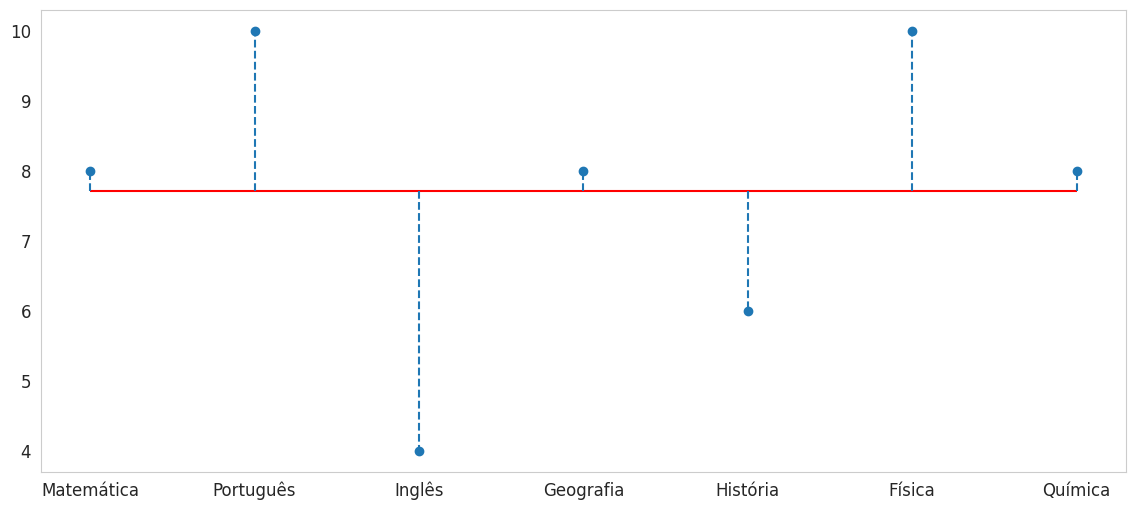

In [166]:
ax = notas_fulano['Fulano'].plot(style='o')
ax.figure.set_size_inches(14, 6)
ax.hlines(y=nota_media_fulano, xmin=0, xmax=notas_fulano.shape[0]-1, colors='red')
for i in range(notas_fulano.shape[0]):
    ax.vlines(x=i, ymin=nota_media_fulano, ymax=notas_fulano['Fulano'].iloc[i], linestyles='dashed')
ax

In [167]:
print(notas_fulano['|Desvio|'].mean())

1.5510204081632648


```mad()``` foi depreciada a partir da versão 1.5.0 do Pandas. Abaixo uma outra forma de fazer o cálculo:

In [168]:
desvio_medio_absoluto_fulano = ((notas_fulano - notas_fulano.mean()).abs().mean()).iloc[0]
print(desvio_medio_absoluto_fulano)

1.5510204081632648


## <font color=green>5.2 Variância</font>
***

### Variância

A variância é construída a partir das diferenças entre cada observação e a média dos dados, ou seja, o desvio em torno da média. No cálculo da variância, os desvios em torno da média são elevados ao quadrado.

### Variância populacional

# $$\sigma^2 = \frac 1n\sum_{i=1}^{n}(X_i-\mu)^2$$

### Variância amostral

# $$S^2 = \frac 1{n-1}\sum_{i=1}^{n}(X_i-\bar{X})^2$$

In [169]:
notas_fulano['(Desvio)^2'] = notas_fulano['Desvio'].pow(2)
notas_fulano

Matérias,Fulano,Desvio,|Desvio|,(Desvio)^2
Matemática,8,0.285714,0.285714,0.081633
Português,10,2.285714,2.285714,5.224490
Inglês,4,-3.714286,3.714286,13.795918
Geografia,8,0.285714,0.285714,0.081633
História,6,-1.714286,1.714286,2.938776
Física,10,2.285714,2.285714,5.224490
Química,8,0.285714,0.285714,0.081633


In [170]:
notas_fulano['(Desvio)^2'].sum() / (len(notas_fulano['Desvio']) - 1)

4.57142857142857

In [171]:
variancia = notas_fulano['Fulano'].var()
variancia

4.57142857142857

In [172]:
notas_fulano['(Desvio)^2'].sum() / (len(notas_fulano['Desvio']))

3.918367346938775

In [173]:
#desviopadrão populacional:
desvio_padrao_pop = notas_fulano['Fulano'].std(ddof=0)
desvio_padrao_pop

1.9794866372215738

## <font color=green>5.3 Desvio padrão</font>
***

Uma das restrições da variância é o fato de fornecer medidas em quadrados das unidades originais - a variância de medidas de comprimento, por exemplo, é em unidades de área. Logo, o fato de as unidades serem diferentes dificulta a comparação da dispersão com as variáveis que a definem. Um modo de eliminar essa dificuldade é considerar sua raiz quadrada.

### Desvio padrão populacional

# $$\sigma = \sqrt{\frac 1n\sum_{i=1}^{n}(X_i-\mu)^2} \Longrightarrow \sigma = \sqrt{\sigma^2}$$

### Desvio padrão amostral

# $$S = \sqrt{\frac 1{n-1}\sum_{i=1}^{n}(X_i-\bar{X})^2} \Longrightarrow S = \sqrt{S^2}$$

Desvio padrão amostral:

In [174]:
np.sqrt(variancia)

2.1380899352993947

In [175]:
desvio_padrao = notas_fulano['Fulano'].std()
desvio_padrao

2.1380899352993947

In [182]:
variancia_pop = notas_fulano['(Desvio)^2'].sum() / len(notas_fulano['Desvio'])
np.sqrt(variancia_pop)

1.9794866372215738

Desvio padrão populacional:

In [183]:
desvio_padrao_pop = notas_fulano['Fulano'].std(ddof=0)
desvio_padrao_pop

1.9794866372215738

In [184]:
df

Matérias,Fulano,Beltrano,Sicrano
Matemática,8,10.0,7.5
Português,10,2.0,8.0
Inglês,4,0.5,7.0
Geografia,8,1.0,8.0
História,6,3.0,8.0
Física,10,9.5,8.5
Química,8,10.0,7.0


In [185]:
df.mean()

,0
Matérias,
Fulano,7.714286
Beltrano,5.142857
Sicrano,7.714286


In [186]:
df.median()

,0
Matérias,
Fulano,8.0
Beltrano,3.0
Sicrano,8.0


In [187]:
df.mode()

Matérias,Fulano,Beltrano,Sicrano
0,8,10.0,8.0


In [188]:
#metodo mad() não funciona mais pois foi depreciado na versão 1.5 do Pandas
# forma alternativa de realizar o cálculo
((df - df.mean()).abs().mean())

,0
Matérias,
Fulano,1.551020
Beltrano,4.020408
Sicrano,0.469388


In [189]:
df.var()

,0
Matérias,
Fulano,4.571429
Beltrano,19.892857
Sicrano,0.321429


In [190]:
df.std()

,0
Matérias,
Fulano,2.138090
Beltrano,4.460141
Sicrano,0.566947


O desvio padrão das matérias pode ser calculado tomando-se a transposta do DataFrame.

In [191]:
df.T.std()

,0
Matemática,1.322876
Português,4.163332
Inglês,3.253204
Geografia,4.041452
História,2.516611
Física,0.763763
Química,1.527525


In [192]:
valor = dataset = pd.DataFrame({
    'Sexo': ['H', 'M', 'M', 'M', 'M', 'H', 'H', 'H', 'M', 'M'],
    'Idade': [53, 72, 54, 27, 30, 40, 58, 32, 44, 51]
})

In [193]:
%%timeit
valor.groupby('Sexo').std().loc['M']
valor

859 µs ± 117 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


In [194]:
%%timeit
valor['Idade'].groupby(dataset['Sexo'] == 'M').std()
valor

388 µs ± 10.7 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)
